In [284]:
import numpy as np
import pandas as pd
import nltk
import torch.nn.functional as F
from torchtext.vocab import GloVe,vocab
from torchtext.data.functional import to_map_style_dataset

In [2]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Amrita\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
train_df=pd.read_csv("IMDB Dataset.csv",header=None)

In [4]:
train_df.columns=['Comment',"Sentiment"]

In [5]:
train_df=train_df.drop([0],axis=0)

In [6]:
df=train_df.sample(1000)
texts = df["Comment"]
# texts_transformed = []
# for review in texts:
#     sentences = nltk.sent_tokenize(review)
#     adjectives = []
    
    
#     for sentence in sentences:
#         words = nltk.word_tokenize(sentence) 
#         words_tagged = nltk.pos_tag(words)
        
#         adj_add = [adjectives.append(word_tagged[0]) for word_tagged in words_tagged if word_tagged[1] == "JJ"]
                
#     texts_transformed.append(" ".join(adjectives)) 

In [7]:
df.reset_index(drop=True,inplace=True)

In [8]:
texts1=train_df.iloc[~train_df.index.isin(texts.index.to_list()),:].sample(2000)

In [9]:
texts.reset_index(drop=True,inplace=True)

In [10]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from collections import Counter
import math

# Download NLTK resources (only need to do this once)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')

def calculate_entropy(word_counts):
    total_count = sum(word_counts.values())
    entropy = -sum((count / total_count) * math.log2(count / total_count) for count in word_counts.values())
    return entropy

def extract_nouns_with_entropy(text, window_size=5):
    # Tokenize the text
    tokens = word_tokenize(text.lower())
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    # Perform POS tagging
    tagged_tokens = pos_tag(filtered_tokens)
    
    # Create co-occurrence matrix
    co_occurrence_matrix = Counter()
    for i, (word, tag) in enumerate(tagged_tokens):
        if tag.startswith('NN'):  # Focus on nouns
            context_words = filtered_tokens[max(0, i-window_size):i] + filtered_tokens[i+1:i+1+window_size]
            for context_word in context_words:
                if context_word != word:
                    co_occurrence_matrix[(word, context_word)] += 1
    
    # Calculate branching entropy for nouns
    word_entropy = Counter()
    for (word, _), count in co_occurrence_matrix.items():
        word_entropy[word] += count
    
    entropies = {word: calculate_entropy({context: count for (w, context), count in co_occurrence_matrix.items() if w == word})
                 for word in word_entropy}
    
    # Set a threshold for noun extraction
    threshold = sorted(entropies.values(), reverse=True)[int(0.5 * len(entropies))]
    nouns = [word for word, entropy in entropies.items() if entropy >= threshold]
    
    return nouns, entropies


nouns=[]
entropies=[]
for i in texts:
    nn, entr = extract_nouns_with_entropy(i)
    nouns.append(nn)
    entropies.append(entr)
print("Extracted Nouns:", nouns)
print("Nouns with Branching Entropy:", entropies)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Amrita\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Amrita\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Amrita\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Extracted Nouns: [['smith', 'film', 'world', 'shoulders', 'wrongs', 'way', 'director', 'gabriele', 'muccino', 'masterpiece', 'purchase', 'movie', 'collection', 'actor', 'tell', 'love', 'people', 'life', 'doubt', 'character', 'agent', 'ben', 'thomas', 'pain', 'woody', 'harrelson', 'notch', 'review', 'plot', 'points', 'thank'], ['heroes', 'dragon', 'world', 'islands', 'clouds', 'leaps', 'island', 'journey', 'water', 'flow', 'upwards', 'cities', 'horizon', '<', 'br', '/', '>', 'movie', 'accident', 'movies', 'pixar', 'piece', 'computer', 'today', 'animators', 'everything', 'attention', 'detail', 'staggering', 'scene', 'mushrooms', 'smoke', 'whilst', 'characters', 'favourites', 'monsters', 'watch', 'plot', 'charm', 'watching', 'protagonists', 'audience', 'reach', 'end', 'destroy', 'path', 'course', 'hector', 'love', 'creature', 'grin', 'tendency', 'mixture', 'english', 'way', 'hunters', 'opportunity', 'animation', 'battle', 'scenes', 'anything', 'cinema', 'television', 'screen', 'hour', 'ha

In [11]:
from collections import defaultdict, Counter
def calculate_accessor_variety(tokens, window_size=5):
    # Create dictionaries to store forward and backward contexts
    forward_contexts = defaultdict(set)
    backward_contexts = defaultdict(set)
    
    # Populate the context dictionaries
    for i, word in enumerate(tokens):
        if i > 0:
            backward_contexts[word].add(tokens[i-1])
        if i < len(tokens) - 1:
            forward_contexts[word].add(tokens[i+1])
    
    # Calculate forward and backward accessor variety
    fav = {word: len(context) for word, context in forward_contexts.items()}
    bav = {word: len(context) for word, context in backward_contexts.items()}
    
    # Calculate total accessor variety
    tav = {word: fav.get(word, 0) + bav.get(word, 0) for word in set(tokens)}
    
    return fav, bav, tav

def extract_nouns_with_accessor_variety(text, window_size=5):
    # Tokenize the text
    tokens = word_tokenize(text.lower())
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    # Perform POS tagging
    tagged_tokens = pos_tag(filtered_tokens)
    
    # Calculate accessor variety
    fav, bav, tav = calculate_accessor_variety(filtered_tokens, window_size)
    
    # Extract nouns based on accessor variety
    threshold = sorted(tav.values(), reverse=True)[int(0.5 * len(tav))]
    nouns = [word for word, av in tav.items() if av >= threshold and any(tag.startswith('NN') for word, tag in tagged_tokens if word == word)]
    
    return nouns, fav, bav, tav

# text = "The quick brown fox jumps over the lazy dog."
# nouns, fav, bav, tav = extract_nouns_with_accessor_variety(text)
# print("Extracted Nouns:", nouns)
# print("Forward Accessor Variety:", fav)
# print("Backward Accessor Variety:", bav)
# print("Total Accessor Variety:", tav)


nouns1=[]
avs=[]
for i in texts:
    nn, fav, bav, tav = extract_nouns_with_accessor_variety(i)
    nouns1.append(nn)
    avs.append((fav,bav,tav))
print("Extracted Nouns:", nouns1)
print("Nouns with Branching Entropy:", avs)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [12]:
nouns1

[['anger',
  'giving',
  'frustrations',
  'recommend',
  'touch',
  'director',
  'created',
  'world',
  'collection',
  'say',
  'nieporte',
  'grow',
  'gabriele',
  'highly',
  'another',
  'writer',
  'made',
  'agent',
  'tell',
  'thomas',
  ',',
  'one',
  'shoulders',
  'found',
  'life',
  'film',
  'grant',
  'usual',
  'falling',
  'character',
  'stars',
  'masterpiece',
  'top',
  'back',
  'unravel',
  'movie',
  'feeling',
  'perfect',
  ')',
  'even',
  'genuine',
  'respects',
  'away',
  'points',
  'phone',
  'people',
  'man',
  'muccino',
  'woody',
  'sit',
  'right',
  '!',
  'past',
  'harrelson',
  'hardened',
  'find',
  'also',
  'irs',
  'rosario',
  'dawson',
  'never',
  'take',
  'doubt',
  'ready',
  'fact',
  'review',
  'ben',
  'yet',
  'wrongs',
  'start',
  'get',
  'tired',
  'difficult',
  'played',
  'make',
  '.',
  'interrupt',
  '(',
  'key',
  'thank',
  'italian',
  'purchase',
  'trying',
  'brilliant',
  'hearts',
  'keep',
  'characters

In [13]:
def calculate_mutual_information(word_counts, bigram_counts, total_bigrams, word1, word2):
    p_word1 = word_counts[word1] / total_bigrams
    p_word2 = word_counts[word2] / total_bigrams
    p_word1_word2 = bigram_counts[(word1, word2)] / total_bigrams
    if p_word1_word2 == 0:
        return 0
    return math.log2(p_word1_word2 / (p_word1 * p_word2))

def calculate_cohesion_score(tokens, window_size=2):
    word_counts = Counter(tokens)
    bigram_counts = Counter(zip(tokens, tokens[1:]))
    total_bigrams = len(tokens) - 1
    
    cohesion_scores = {}
    for i in range(len(tokens) - window_size + 1):
        phrase = tuple(tokens[i:i+window_size])
        cohesion_score = sum(calculate_mutual_information(word_counts, bigram_counts, total_bigrams, phrase[j], phrase[j+1])
                             for j in range(len(phrase) - 1))
        cohesion_scores[phrase] = cohesion_score
    
    return cohesion_scores

def extract_nouns_with_cohesion_score(text, window_size=2):
    # Tokenize the text
    tokens = word_tokenize(text.lower())
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    # Perform POS tagging
    tagged_tokens = pos_tag(filtered_tokens)
    
    # Calculate cohesion scores
    cohesion_scores = calculate_cohesion_score(filtered_tokens, window_size)
    
    # Extract noun phrases based on cohesion score
    threshold = sorted(cohesion_scores.values(), reverse=True)[int(0.5 * len(cohesion_scores))]
    noun_phrases = [' '.join(phrase) for phrase, score in cohesion_scores.items() if score >= threshold and any(tag.startswith('NN') for word, tag in tagged_tokens if word in phrase)]
    
    return noun_phrases, cohesion_scores

nouns2=[]
cohension_scores=[]
for i in texts:
    nn, ch = extract_nouns_with_cohesion_score(i)
    nouns2.append(nn)
    cohension_scores.append(ch)
print("Extracted Nouns:", nouns2)
print("Nouns with Branching Entropy:", cohension_scores)

Extracted Nouns: [['delivers yet', 'man weight', 'weight world', 'world shoulders', 'shoulders crusade', 'right wrongs', 'hardened hearts', 'writer grant', 'grant nieporte', 'italian director', 'director gabriele', 'gabriele muccino', 'muccino come', 'created masterpiece', 'masterpiece highly', 'recommend purchase', 'purchase keep', 'keep movie', 'movie collection', 'collection never', 'tired watching/feeling', 'highest respects', 'brilliant actor', 'actor one', 'one tell', 'tell genuine', 'doubt made', 'perfect character', 'character (', 'feeling pain', 'pain anger', 'rosario dawson', 'fact characters', 'woody harrelson', 'harrelson also', 'top notch', 'write review', 'review without', 'key plot', 'plot points', 'sure nothing', 'nothing interrupt', 'take phone', 'phone hook'], ['heard story', 'story reluctant', 'reluctant heroes', 'heroes hired', 'king slay', 'small islands', 'islands floating', 'floating clouds', 'dangerous leaps', 'island next', 'next journey', 'water flow', 'flow u

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [14]:
contractions=pd.read_csv('contractions.csv')
a=contractions[contractions.columns[0]].to_list()
b=contractions[contractions.columns[1]].to_list()

In [15]:
contractions={i:j for i,j in zip(a,b)}

In [16]:
def expand(x):
    ## Pass the text
    tokens=x.split(" ")
    for i in tokens:
        for key,values in contractions.items():
            if key==i:
                tokens[tokens.index(i)]=values
    return " ".join(tokens)

In [17]:
from num2words import num2words
def numtowords(x):
    tokens=x.split(" ")
    for i in tokens:
        if i.isdigit():
            tokens[tokens.index(i)]=num2words(i,to='ordinal')
    return " ".join(tokens)

In [18]:
## Rare words removal:- Perform word-embedding and use similarity scores to calculate close words

In [19]:
# https://www.scaler.com/topics/nlp/create-a-spell-check-with-nlp/

In [20]:
# Define Spell Checker class
class SpellChecker:
    
    def __init__(self, term_freq):
        "Constructor."
        self.w_rank = {}
        self.letters = 'abcdefghijklmnopqrstuvwxyz'
        
        N = sum(term_freq.values())
        for term in term_freq:
            self.w_rank[term] = term_freq[term] / N
    
    def P(self, word): 
        "Probability of 'word'."
        return self.w_rank.get(word, 0)

    def known(self, words): 
        "The subset of 'words' that appear in the dictionary of w_rank."
        return set(w for w in words if w in self.w_rank)

    def edits1(self, word):
        "All edits that are one edit away from 'word'."
        splits     = [(word[:i], word[i:])    for i in range(len(word) + 1)]
        deletes    = [L + R[1:]               for L, R in splits if R]
        transposes = [L + R[1] + R[0] + R[2:] for L, R in splits if len(R) > 1]
        replaces   = [L + c + R[1:]           for L, R in splits if R for c in self.letters]
        inserts    = [L + c + R               for L, R in splits for c in self.letters]
        
        return set(deletes + transposes + replaces + inserts)

    def edits2(self, word): 
        "All edits that are two edits away from 'word'."
        return (e2 for e1 in self.edits1(word) for e2 in self.edits1(e1))
    
    def correction(self, word):
        "Most probable spelling correction for word."
        return max(self.candidates(word), key = self.P)
    
    def candidates(self, word): 
        "Generate possible spelling corrections for word."
        return (self.known([word]) or self.known(self.edits1(word)) or self.known(self.edits2(word)) or [word])

In [21]:
from nltk.corpus import brown, movie_reviews

In [22]:
word_corpus=[word for word in movie_reviews.words(categories=['neg','pos'])]

In [23]:
# Create term frequency list of the document words
term_freq = Counter(word_corpus)

In [24]:
# Create model
sp_model = SpellChecker(term_freq)

In [25]:
def spell_check(x):
    y=" ".join([sp_model.correction(token) for token in x.split(" ")])
    return y

In [26]:
def remove_extra_spaces(x):
    return re.sub(r"\s+", " ", x)

In [27]:
def singularize(x):
    text=Word(x)
    y=" ".join([Word(token).singularize() for token in x.split(" ") if token not in ('this')])
    return y

In [28]:
from textblob import TextBlob,Word
import re

def spell(x):
    return str(TextBlob(x).correct())


In [29]:
df['Comment']=df['Comment'].apply(expand)
print("done")
df['Comment']=df['Comment'].apply(numtowords)
print("done")
# df['Comment']=df['Comment'].apply(spell)
# print("done")
df['Comment']=df['Comment'].apply(remove_extra_spaces)
print("done")
df['Comment']=df['Comment'].apply(singularize)
print("done")

done
done
done
done


In [30]:
## Torchtext tutorial

In [31]:
test=df.iloc[:,0]
test.to_csv('test.csv',index=False)

In [32]:
from torchtext.data.functional import generate_sp_model
generate_sp_model('test.csv',vocab_size=10000,model_type='unigram',model_prefix='spm_user_unigram')

In [33]:
from torchtext.data.functional import generate_sp_model
generate_sp_model('test.csv',model_type='bpe',model_prefix='spm_user_bpe')

In [34]:
from torchtext.data.functional import generate_sp_model
generate_sp_model('test.csv',model_type='word',model_prefix='spm_user_word')

In [35]:
from torchtext.data.functional import load_sp_model
unigram=load_sp_model("spm_user_unigram.model")
bpe=load_sp_model("spm_user_bpe.model")
word=load_sp_model("spm_user_word.model")

In [36]:
from torchtext.data.functional import sentencepiece_numericalizer
sp_id_generator_unigram=sentencepiece_numericalizer(unigram)
sp_id_generator_bpe=sentencepiece_numericalizer(bpe)
sp_id_generator_word=sentencepiece_numericalizer(word)

In [10]:
lst=df['Comment'].to_list()[0:20]
# list(sp_id_generator_word(lst))
# list(sp_id_generator_bpe(lst))
# list(sp_id_generator_unigram(lst))

In [38]:
from torchtext.data.functional import sentencepiece_tokenizer
sp_id_generator_unigram_tkn=sentencepiece_tokenizer(unigram)
sp_id_generator_bpe_tkn=sentencepiece_tokenizer(bpe)
sp_id_generator_word_tkn=sentencepiece_tokenizer(word)

In [39]:
lst=df['Comment'].to_list()[0:20]
list(sp_id_generator_unigram_tkn(lst))
list(sp_id_generator_bpe_tkn(lst))
list(sp_id_generator_word_tkn(lst))

[['▁Will',
  '▁Smith',
  '▁deliver',
  '▁yet',
  '▁again',
  '▁in',
  '▁a',
  '▁film',
  '▁about',
  '▁a',
  '▁man',
  '▁with',
  '▁the',
  '▁weight',
  '▁of',
  '▁the',
  '▁world',
  '▁on',
  '▁shoulder',
  '▁and',
  '▁crusade',
  '▁to',
  '▁right',
  '▁wrong',
  '▁in',
  '▁a',
  '▁way',
  '▁that',
  '▁will',
  '▁touch',
  '▁even',
  '▁the',
  '▁most',
  '▁hardened',
  '▁of',
  '▁hearts!!!',
  '▁Writer',
  '▁Grant',
  '▁Nieporte',
  '▁and',
  '▁Italian',
  '▁Director',
  '▁Gabriele',
  '▁Muccino',
  '▁come',
  '▁together',
  '▁and',
  '▁created',
  '▁a',
  '▁masterpiece',
  '▁that',
  '▁I',
  '▁highly',
  '▁recommend',
  '▁to',
  '▁purchase',
  '▁and',
  '▁keep',
  '▁in',
  '▁ymy',
  '▁movie',
  '▁collection',
  '▁a',
  '▁you',
  '▁will',
  '▁never',
  '▁grow',
  '▁tired',
  '▁of',
  '▁watching/feeling▁film!!!',
  '▁I',
  '▁have',
  '▁the',
  '▁Highest',
  '▁Respect',
  '▁for',
  '▁Will',
  '▁Smith',
  '▁a',
  '▁he',
  '▁not',
  '▁only',
  '▁a',
  '▁brilliant',
  '▁Actor',
  '▁but',
 

In [40]:
from torchtext.data.functional import simple_space_split

list(simple_space_split(lst))

[['Will',
  'Smith',
  'deliver',
  'yet',
  'again',
  'in',
  'a',
  'film',
  'about',
  'a',
  'man',
  'with',
  'the',
  'weight',
  'of',
  'the',
  'world',
  'on',
  'shoulder',
  'and',
  'crusade',
  'to',
  'right',
  'wrong',
  'in',
  'a',
  'way',
  'that',
  'will',
  'touch',
  'even',
  'the',
  'most',
  'hardened',
  'of',
  'hearts!!!',
  'Writer',
  'Grant',
  'Nieporte',
  'and',
  'Italian',
  'Director',
  'Gabriele',
  'Muccino',
  'come',
  'together',
  'and',
  'created',
  'a',
  'masterpiece',
  'that',
  'I',
  'highly',
  'recommend',
  'to',
  'purchase',
  'and',
  'keep',
  'in',
  'ymy',
  'movie',
  'collection',
  'a',
  'you',
  'will',
  'never',
  'grow',
  'tired',
  'of',
  'watching/feeling',
  'film!!!',
  'I',
  'have',
  'the',
  'Highest',
  'Respect',
  'for',
  'Will',
  'Smith',
  'a',
  'he',
  'not',
  'only',
  'a',
  'brilliant',
  'Actor',
  'but',
  'one',
  'can',
  'tell',
  'he',
  'ha',
  'a',
  'genuine',
  'love',
  'for',

In [41]:
from torchtext.data.functional import numericalize_tokens_from_iterator

from torchtext.vocab import vocab

In [11]:
import torchtext
from torchtext.data import get_tokenizer

tokenizer=get_tokenizer("basic_english")
tokenizer(lst[0])

['i',
 'give',
 'this',
 'movie',
 'a',
 '3',
 'as',
 'it',
 'is',
 'worse',
 'than',
 'the',
 'cult',
 'movies',
 'that',
 'deserve',
 'a',
 'proper',
 '2',
 '.',
 'it',
 'does',
 'not',
 'make',
 'sense',
 'to',
 'you',
 '?',
 'well',
 ',',
 'it',
 'doesn',
 "'",
 't',
 'have',
 'to',
 '.',
 'this',
 'is',
 'another',
 'vampire',
 'movie',
 'with',
 'a',
 'stupid',
 'plot',
 ',',
 'no',
 ',',
 'let',
 'me',
 'rephrase',
 ',',
 'incredibly',
 'idiotic',
 'plot',
 ',',
 'where',
 'space',
 'cowboys',
 '(',
 'complete',
 'with',
 'cowboy',
 'hats',
 ')',
 'battle',
 'a',
 'space',
 'race',
 'of',
 'moron',
 'vampires',
 '.',
 'does',
 'it',
 'get',
 'any',
 'uglier',
 'than',
 'this',
 '?',
 'the',
 'only',
 'good',
 'thing',
 'in',
 'this',
 'movie',
 'was',
 'natassia',
 'malthe',
 ',',
 'with',
 'her',
 'stunning',
 'norwegian',
 'beauty',
 '.',
 'god',
 ',',
 'i',
 'wish',
 'michael',
 'ironside',
 'and',
 'the',
 'deluise',
 'brothers',
 'would',
 'stop',
 'accepting',
 'dumb',
 'r

In [43]:
from torchtext.data.utils import ngrams_iterator

list(ngrams_iterator(tokenizer(lst[0]),5))

['will',
 'smith',
 'deliver',
 'yet',
 'again',
 'in',
 'a',
 'film',
 'about',
 'a',
 'man',
 'with',
 'the',
 'weight',
 'of',
 'the',
 'world',
 'on',
 'shoulder',
 'and',
 'crusade',
 'to',
 'right',
 'wrong',
 'in',
 'a',
 'way',
 'that',
 'will',
 'touch',
 'even',
 'the',
 'most',
 'hardened',
 'of',
 'hearts',
 '!',
 '!',
 '!',
 'writer',
 'grant',
 'nieporte',
 'and',
 'italian',
 'director',
 'gabriele',
 'muccino',
 'come',
 'together',
 'and',
 'created',
 'a',
 'masterpiece',
 'that',
 'i',
 'highly',
 'recommend',
 'to',
 'purchase',
 'and',
 'keep',
 'in',
 'ymy',
 'movie',
 'collection',
 'a',
 'you',
 'will',
 'never',
 'grow',
 'tired',
 'of',
 'watching/feeling',
 'film',
 '!',
 '!',
 '!',
 'i',
 'have',
 'the',
 'highest',
 'respect',
 'for',
 'will',
 'smith',
 'a',
 'he',
 'not',
 'only',
 'a',
 'brilliant',
 'actor',
 'but',
 'one',
 'can',
 'tell',
 'he',
 'ha',
 'a',
 'genuine',
 'love',
 'for',
 'person',
 'and',
 'life',
 'which',
 'no',
 'doubt',
 'made',
 

In [12]:
lst_new=[(i,text) for i,text in enumerate(lst)]

In [13]:
from torchtext.vocab import build_vocab_from_iterator

def yield_tokens(data_iter):
    for _,text in data_iter:
        yield tokenizer(text)

my_iterator=yield_tokens(lst_new)
# next(my_iterator)

vocab=build_vocab_from_iterator(yield_tokens(lst_new),specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

In [47]:
# vocab.get_stoi()
vocab.get_itos()[100:110]

['any',
 'because',
 'can',
 'come',
 'find',
 'going',
 'here',
 'man',
 'never',
 'only']

In [48]:
from torchtext.vocab import Vectors

vcs=Vectors('glove.6B.50d.txt')

def vector(x):
    return vcs.get_vecs_by_tokens(x)

for i in vocab.get_itos()[100:110]:
    print(vector(i))

100%|██████████████████████████████████████████████████████████████████████▉| 400000/400001 [00:34<00:00, 11581.40it/s]


tensor([ 5.1292e-01,  9.0320e-02,  2.3552e-02,  2.1438e-01,  7.0226e-01,
         5.6230e-01,  1.1839e-01,  2.5641e-01, -3.9706e-02,  9.5389e-02,
        -1.5477e-02,  3.7808e-01, -1.6160e-01, -1.8322e-01,  8.0726e-01,
         5.2100e-01,  4.0167e-01, -5.1684e-01, -5.6347e-02, -9.5212e-01,
         4.2801e-02, -8.2442e-02,  2.3867e-01, -1.0777e-01,  1.2598e-01,
        -2.0330e+00, -4.8642e-01, -1.8917e-02,  1.0034e+00, -1.6553e-01,
         3.8562e+00,  1.0825e-01, -8.1231e-01, -8.2064e-01,  9.8151e-02,
        -2.5282e-02,  2.7985e-01, -2.8044e-01, -4.0594e-01, -1.4185e-01,
         2.8418e-03, -4.6259e-02,  9.3178e-02,  9.3830e-01, -3.9413e-02,
        -3.5659e-01, -3.3987e-01,  1.1585e+00,  2.9796e-01,  7.5048e-02])
tensor([ 0.5290, -0.3015,  0.0562, -0.1790,  0.1567,  0.3294, -0.4591,  0.3741,
        -0.0728,  0.2611,  0.3634,  0.2312, -0.3808, -0.3568,  1.0069,  0.8395,
         0.0747, -0.1356, -0.1017, -0.7086, -0.3825,  0.0081,  0.2661, -0.0146,
         0.1663, -2.2449, -0.

In [50]:
vcs1=torchtext.vocab.FastText(language='en')
vcs1.get_vecs_by_tokens(['baby','animal'], lower_case_backup=True)


# torchtext.vocab.CharNGram(**kwargs)

.vector_cache\wiki.en.vec:   1%|▍                                                 | 49.8M/6.60G [00:07<15:35, 7.00MB/s]


KeyboardInterrupt: 

In [59]:
from torchtext.transforms import SentencePieceTokenizer

transform=SentencePieceTokenizer("spm_user_word.model")
transform(lst[0:2])

[['▁Will',
  '▁Smith',
  '▁deliver',
  '▁yet',
  '▁again',
  '▁in',
  '▁a',
  '▁film',
  '▁about',
  '▁a',
  '▁man',
  '▁with',
  '▁the',
  '▁weight',
  '▁of',
  '▁the',
  '▁world',
  '▁on',
  '▁shoulder',
  '▁and',
  '▁crusade',
  '▁to',
  '▁right',
  '▁wrong',
  '▁in',
  '▁a',
  '▁way',
  '▁that',
  '▁will',
  '▁touch',
  '▁even',
  '▁the',
  '▁most',
  '▁hardened',
  '▁of',
  '▁hearts!!!',
  '▁Writer',
  '▁Grant',
  '▁Nieporte',
  '▁and',
  '▁Italian',
  '▁Director',
  '▁Gabriele',
  '▁Muccino',
  '▁come',
  '▁together',
  '▁and',
  '▁created',
  '▁a',
  '▁masterpiece',
  '▁that',
  '▁I',
  '▁highly',
  '▁recommend',
  '▁to',
  '▁purchase',
  '▁and',
  '▁keep',
  '▁in',
  '▁ymy',
  '▁movie',
  '▁collection',
  '▁a',
  '▁you',
  '▁will',
  '▁never',
  '▁grow',
  '▁tired',
  '▁of',
  '▁watching/feeling▁film!!!',
  '▁I',
  '▁have',
  '▁the',
  '▁Highest',
  '▁Respect',
  '▁for',
  '▁Will',
  '▁Smith',
  '▁a',
  '▁he',
  '▁not',
  '▁only',
  '▁a',
  '▁brilliant',
  '▁Actor',
  '▁but',
 

In [60]:
import os
import urllib.request

def download_file_if_absent(url, filename):
    if not os.path.exists(filename):
        try:
            with urllib.request.urlopen(url) as response, open(filename, 'wb') as out_file:
                out_file.write(response.read())
            print(f"Downloaded {filename}")
        except Exception as e:
            print(f"Failed to download {filename}. Error: {e}")
    else:
        print(f"{filename} already exists")

files_to_download = {
    "https://openaipublic.blob.core.windows.net/gpt-2/models/124M/vocab.bpe": "vocab.bpe",
    "https://openaipublic.blob.core.windows.net/gpt-2/models/124M/encoder.json": "encoder.json"
}

for url, filename in files_to_download.items():
    download_file_if_absent(url, filename)

Downloaded vocab.bpe
Downloaded encoder.json


In [63]:
from torchtext.transforms import GPT2BPETokenizer

tokenizer=GPT2BPETokenizer('encoder.json','vocab.bpe',return_tokens=True)
tokenizer(lst[0:2])

[['Will',
  'ĠSmith',
  'Ġdeliver',
  'Ġyet',
  'Ġagain',
  'Ġin',
  'Ġa',
  'Ġfilm',
  'Ġabout',
  'Ġa',
  'Ġman',
  'Ġwith',
  'Ġthe',
  'Ġweight',
  'Ġof',
  'Ġthe',
  'Ġworld',
  'Ġon',
  'Ġshoulder',
  'Ġand',
  'Ġcrusade',
  'Ġto',
  'Ġright',
  'Ġwrong',
  'Ġin',
  'Ġa',
  'Ġway',
  'Ġthat',
  'Ġwill',
  'Ġtouch',
  'Ġeven',
  'Ġthe',
  'Ġmost',
  'Ġhardened',
  'Ġof',
  'Ġhearts',
  '!!!',
  'ĠWriter',
  'ĠGrant',
  'ĠN',
  'ie',
  'port',
  'e',
  'Ġand',
  'ĠItalian',
  'ĠDirector',
  'ĠGab',
  'rie',
  'le',
  'ĠMu',
  'cc',
  'ino',
  'Ġcome',
  'Ġtogether',
  'Ġand',
  'Ġcreated',
  'Ġa',
  'Ġmasterpiece',
  'Ġthat',
  'ĠI',
  'Ġhighly',
  'Ġrecommend',
  'Ġto',
  'Ġpurchase',
  'Ġand',
  'Ġkeep',
  'Ġin',
  'Ġy',
  'my',
  'Ġmovie',
  'Ġcollection',
  'Ġa',
  'Ġyou',
  'Ġwill',
  'Ġnever',
  'Ġgrow',
  'Ġtired',
  'Ġof',
  'Ġwatching',
  '/',
  'fe',
  'eling',
  'Ġfilm',
  '!!!',
  'ĠI',
  'Ġhave',
  'Ġthe',
  'ĠHighest',
  'ĠRespect',
  'Ġfor',
  'ĠWill',
  'ĠSmith',
  

In [65]:
from torchtext.transforms import CLIPTokenizer
MERGES_FILE = "http://download.pytorch.org/models/text/clip_merges.bpe"
ENCODER_FILE = "http://download.pytorch.org/models/text/clip_encoder.json"
tokenizer = CLIPTokenizer(merges_path=MERGES_FILE, encoder_json_path=ENCODER_FILE)
tokenizer(lst[0:2])

[['751',
  '2915',
  '7396',
  '2296',
  '1495',
  '530',
  '320',
  '1860',
  '781',
  '320',
  '786',
  '593',
  '518',
  '3868',
  '539',
  '518',
  '1002',
  '525',
  '8476',
  '537',
  '36846',
  '531',
  '1155',
  '3669',
  '530',
  '320',
  '923',
  '682',
  '751',
  '4526',
  '1427',
  '518',
  '1096',
  '915',
  '19571',
  '539',
  '5516',
  '995',
  '4422',
  '5442',
  '9524',
  '28654',
  '537',
  '5175',
  '2681',
  '8311',
  '9766',
  '670',
  '66',
  '18616',
  '891',
  '1952',
  '537',
  '4080',
  '320',
  '12066',
  '682',
  '328',
  '5302',
  '8942',
  '531',
  '5481',
  '537',
  '1726',
  '530',
  '88',
  '607',
  '2016',
  '2548',
  '320',
  '592',
  '751',
  '1426',
  '4559',
  '6533',
  '539',
  '2113',
  '270',
  '3045',
  '1860',
  '995',
  '328',
  '720',
  '518',
  '5317',
  '4916',
  '556',
  '751',
  '2915',
  '320',
  '797',
  '783',
  '1033',
  '320',
  '4106',
  '4035',
  '767',
  '637',
  '753',
  '2330',
  '797',
  '1429',
  '320',
  '12184',
  '793',
  

In [75]:
sentences=['I wish I was little bit taller',
'I wish I was a baller',
'She wore a small black dress to the party',
'The dog chased a big red ball in the park',
'He had a huge smile on his face when he won the race',
'The tiny kitten played with a fluffy toy mouse',
'The team celebrated their victory with a grand parade',
'She bought a small, delicate necklace for her sister',
'The mountain peak stood majestic and tall against the clear blue sky',
'The toddler took small, careful steps as she learned to walk',
'The house had a spacious backyard with a big swimming pool',
'He felt a sense of accomplishment after completing the challenging puzzle',
'The chef prepared a delicious, flavorful dish using fresh ingredients',
'The children played happily in the small, cozy room',
'The book had an enormous impact on readers around the world',
'The wind blew gently, rustling the leaves of the tall trees',
'She painted a beautiful, intricate design on the small canvas',
'The concert hall was filled with thousands of excited fans',
'The garden was adorned with colorful flowers of all sizes',
'I hope to achieve great success in my chosen career path',
'The skyscraper towered above the city, casting a long shadow',
'He gazed in awe at the breathtaking view from the mountaintop',
'The artist created a stunning masterpiece with bold brushstrokes',
'The baby took her first steps, a small milestone that brought joy to her parents',
'The team put in a tremendous amount of effort to win the championship',
'The sun set behind the horizon, painting the sky in vibrant colors',
'The professor gave a fascinating lecture on the history of ancient civilizations',
'The house was filled with laughter and the sound of children playing',
'She received a warm, enthusiastic welcome from the audience',
'The marathon runner had incredible endurance and determination',
"The child's eyes sparkled with excitement upon opening the gift",
'The ship sailed across the vast ocean, guided by the stars',
'The company achieved remarkable growth in a short period of time',
'The team worked together harmoniously to complete the project',
'The puppy wagged its tail, expressing its happiness and affection',
'She wore a stunning gown that made her feel like a princess',
'The building had a grand entrance with towering columns',
'The concert was a roaring success, with the crowd cheering and clapping',
'The baby took a tiny bite of the sweet, juicy fruit',
'The athlete broke a new record, achieving a significant milestone in her career',
'The sculpture was a masterpiece of intricate details and craftsmanship',
'The forest was filled with towering trees, creating a sense of serenity',
'The children built a small sandcastle on the beach, their imaginations running wild',
'The mountain range stretched as far as the eye could see, majestic and awe-inspiring',
"The artist's brush glided smoothly across the canvas, creating a beautiful painting",
'She received a small token of appreciation for her hard work and dedication',
'The orchestra played a magnificent symphony that moved the audience to tears',
'The flower bloomed in vibrant colors, attracting butterflies and bees',
'The team celebrated their victory with a big, extravagant party',
"The child's laughter echoed through the small room, filling it with joy",
'The sunflower stood tall, reaching for the sky with its bright yellow petals',
'The city skyline was dominated by tall buildings and skyscrapers',
'The cake was adorned with a beautiful, elaborate design for the special occasion',
'The storm brought heavy rain and strong winds, causing widespread damage',
'The small boat sailed peacefully on the calm, glassy lake',
'The artist used bold strokes of color to create a striking and vivid painting',
'The couple shared a passionate kiss under the starry night sky',
'The mountain climber reached the summit after a long and arduous journey',
"The child's eyes widened in amazement as the magician performed his tricks",
'The garden was filled with the sweet fragrance of blooming flowers',
'The basketball player made a big jump and scored a spectacular slam dunk',
'The cat pounced on a small mouse, displaying its hunting instincts',
'The mansion had a grand entrance with a sweeping staircase and chandeliers',
'The raindrops fell gently, creating a rhythmic patter on the roof',
"The baby took a big step forward, encouraged by her parents' applause",
'The actor delivered a powerful and emotional performance on stage',
'The butterfly fluttered its delicate wings, mesmerizing those who watched',
'The company launched a small-scale advertising campaign to test the market',
'The building was constructed with strong, sturdy materials to withstand earthquakes',
"The singer's voice was powerful and resonated throughout the concert hall",
'The child built a massive sandcastle with towers, moats, and bridges',
'The garden was teeming with a variety of small insects and buzzing bees',
"The athlete's muscles were well-developed and strong from years of training",
'The sun cast long shadows as it set behind the mountains',
'The couple exchanged heartfelt vows in a beautiful, intimate ceremony',
'The dog wagged its tail vigorously, a sign of excitement and happiness',
'The baby let out a tiny giggle, bringing joy to everyone around']

In [79]:
from torchtext.transforms import BERTTokenizer
VOCAB_FILE = "https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt"
tokenizer = BERTTokenizer(vocab_path=VOCAB_FILE, do_lower_case=True, return_tokens=False,strip_accents=True,)
tokenizer("Hello World, How are you!") # single sentence input
tokenizer(sentences[0:5]) # batch input

100%|████████████████████████████████████████████████████████████████████████████████| 232k/232k [00:00<00:00, 654kB/s]


[['1045', '4299', '1045', '2001', '2210', '2978', '12283'],
 ['1045', '4299', '1045', '2001', '1037', '3608', '2121'],
 ['2016', '5078', '1037', '2235', '2304', '4377', '2000', '1996', '2283'],
 ['1996',
  '3899',
  '13303',
  '1037',
  '2502',
  '2417',
  '3608',
  '1999',
  '1996',
  '2380'],
 ['2002',
  '2018',
  '1037',
  '4121',
  '2868',
  '2006',
  '2010',
  '2227',
  '2043',
  '2002',
  '2180',
  '1996',
  '2679']]

In [88]:
from torchtext.transforms import ToTensor

padding=ToTensor(padding_value=1)
padding([[1045, 4299, 1045, 2001, 2210, 2978, 12283],[2001, 2210, 2978, 12283]])

tensor([[ 1045,  4299,  1045,  2001,  2210,  2978, 12283],
        [ 2001,  2210,  2978, 12283,     1,     1,     1]])

In [90]:
from torchtext.transforms import LabelToIndex

l2idx=LabelToIndex(['Cat','Mouse','Dog','Tiger'])
l2idx(['Cat','Cat','Cat','Mouse','Mouse','Dog','Dog','Dog','Tiger','Tiger','Tiger','Tiger'])

[0, 0, 0, 1, 1, 2, 2, 2, 3, 3, 3, 3]

In [91]:
from torchtext.transforms import Truncate

trnc=Truncate(max_seq_len=5)
trnc([[1045, 4299, 1045, 2001, 2210, 2978, 12283],[2001, 2210, 2978, 12283]])

[[1045, 4299, 1045, 2001, 2210], [2001, 2210, 2978, 12283]]

In [93]:
from torchtext.transforms import AddToken

adtkn=AddToken(3899,begin=False)
adtkn([[1045, 4299, 1045, 2001, 2210, 2978, 12283],[2001, 2210, 2978, 12283]])

[[1045, 4299, 1045, 2001, 2210, 2978, 12283, 3899],
 [2001, 2210, 2978, 12283, 3899]]

In [123]:
import torchtext.transforms as T
from torch.hub import load_state_dict_from_url

padding_idx = 1
bos_idx = 0
eos_idx = 2
max_seq_len = 256
xlmr_vocab_path = r"https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt"
xlmr_spm_model_path = r"https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt"

text_transform = T.Sequential(
    T.BERTTokenizer(vocab_path=VOCAB_FILE, do_lower_case=True, return_tokens=False,strip_accents=True),
    T.StrToIntTransform(), ## Above function returns token ids in strings, so we need to convert them to int  
    T.Truncate(max_seq_len - 2),
    T.AddToken(token=bos_idx, begin=True),
    T.AddToken(token=eos_idx, begin=False),

)



100%|████████████████████████████████████████████████████████████████████████████████| 232k/232k [00:00<00:00, 528kB/s]


In [125]:
text_transform(sentences[0:10])

[[0, 1045, 4299, 1045, 2001, 2210, 2978, 12283, 2],
 [0, 1045, 4299, 1045, 2001, 1037, 3608, 2121, 2],
 [0, 2016, 5078, 1037, 2235, 2304, 4377, 2000, 1996, 2283, 2],
 [0, 1996, 3899, 13303, 1037, 2502, 2417, 3608, 1999, 1996, 2380, 2],
 [0,
  2002,
  2018,
  1037,
  4121,
  2868,
  2006,
  2010,
  2227,
  2043,
  2002,
  2180,
  1996,
  2679,
  2],
 [0, 1996, 4714, 18401, 2209, 2007, 1037, 27036, 9121, 8000, 2],
 [0, 1996, 2136, 6334, 2037, 3377, 2007, 1037, 2882, 7700, 2],
 [0, 2016, 4149, 1037, 2235, 1010, 10059, 13016, 2005, 2014, 2905, 2],
 [0,
  1996,
  3137,
  4672,
  2768,
  22337,
  1998,
  4206,
  2114,
  1996,
  3154,
  2630,
  3712,
  2],
 [0,
  1996,
  6927,
  3917,
  2165,
  2235,
  1010,
  6176,
  4084,
  2004,
  2016,
  4342,
  2000,
  3328,
  2]]

In [18]:
## Creating tokens and indices
def get_tokenized_sentence_and_indices(iterator):
    tokenized_sentence=(next(iterator))
    token_indices=[vocab[token] for token in tokenized_sentence]
    return tokenized_sentence,token_indices

# tokenized_sentence,token_indices = get_tokenized_sentence_and_indices(my_iterator)

tokenized_sentence,token_indices = get_tokenized_sentence_and_indices(my_iterator)


In [23]:
get_tokenized_sentence_and_indices(my_iterator)  ## run again and again

(['*warning',
  '1',
  'tiny',
  'inconsequential',
  'spoiler*',
  'you',
  "'",
  're',
  'right',
  '.',
  'this',
  'was',
  'no',
  'bridges',
  'of',
  'madison',
  'county',
  '.',
  'as',
  'soon',
  'as',
  'the',
  'lonely',
  'woman',
  'and',
  'richard',
  'gere',
  'checked',
  'into',
  'the',
  'big',
  'empty',
  'hotel',
  ',',
  'it',
  'was',
  'a',
  'foregone',
  'conclusion',
  'something',
  'kind',
  'of',
  'fun',
  'would',
  'happen',
  '.',
  'the',
  'question',
  'is',
  'how',
  'will',
  'it',
  'come',
  'about',
  '?',
  'the',
  'answer',
  'is',
  'some',
  'stupid',
  'connect-the-dots',
  'story',
  'not',
  'worth',
  'sitting',
  'through',
  '.',
  'in',
  'one',
  'supposed',
  'bonding',
  'experience',
  ',',
  'they',
  'get',
  'drunk',
  'and',
  'clean',
  'out',
  'the',
  'cupboard',
  'of',
  'old',
  'cans',
  '.',
  '(',
  'that',
  'was',
  'my',
  'spoiler',
  '.',
  ')',
  'and',
  'the',
  'next',
  'day',
  'they',
  'put',
  '

In [25]:
text_pipeline=lambda x: vocab(tokenizer(x))
for i in range(0,len(lst_new)):
    print(text_pipeline(lst_new[i][1]))  ## Passing the texts only

[11, 894, 14, 28, 4, 510, 17, 9, 13, 495, 67, 3, 730, 64, 12, 761, 4, 1229, 286, 2, 9, 131, 31, 141, 265, 8, 24, 43, 90, 1, 9, 787, 7, 19, 27, 8, 2, 14, 13, 163, 1488, 28, 16, 4, 273, 115, 1, 44, 1, 243, 50, 1263, 1, 238, 958, 115, 1, 122, 458, 716, 26, 216, 16, 715, 922, 25, 583, 4, 458, 1240, 6, 1106, 1489, 2, 131, 9, 63, 69, 1465, 67, 14, 43, 3, 79, 76, 119, 10, 14, 28, 20, 1121, 1058, 1, 16, 48, 1398, 1136, 585, 2, 229, 1, 11, 1532, 1077, 380, 5, 3, 754, 621, 61, 463, 521, 344, 1283, 10, 344, 64, 29, 11, 402, 1, 34, 1023, 1316, 20, 419, 29, 11, 139, 413, 2, 380, 39, 4, 87, 6, 64, 1, 40, 138, 525, 10, 506, 64, 34, 14, 742, 29, 29, 9, 7, 15, 479, 12, 40, 20, 1242, 10, 4, 1056, 441, 1, 23, 89, 29]
[18, 1385, 1, 11, 130, 7, 19, 108, 139, 74, 14, 81, 269, 4, 499, 51, 37, 46, 6, 3, 983, 2, 11, 27, 31, 255, 192, 9, 22, 1458, 167, 10, 60, 325, 1, 5, 4, 87, 6, 66, 56, 31, 1486, 139, 74, 14, 81, 2, 9, 13, 4, 1198, 120, 1, 46, 14, 13, 348, 3, 78, 256, 5, 676, 202, 11, 27, 1534, 10, 196, 2, 11

In [31]:
from torch import nn

index_to_token=vocab.get_itos()

## Example of embedding

embedding_dim=5
vocab_size=len(vocab)
embeddings=nn.Embedding(vocab_size,embedding_dim)

for i in range(0,10):
    embedding_tensor=embeddings(torch.tensor(i))
    print("Word = {} and index={}".format(index_to_token[i],i))
    print(embedding_tensor,"\n")

Word = <unk> and index=0
tensor([ 0.0373, -0.3471,  0.0502, -0.9345,  2.2005],
       grad_fn=<EmbeddingBackward0>) 

Word = , and index=1
tensor([ 0.0650,  0.3458, -1.7486,  0.1408, -1.0528],
       grad_fn=<EmbeddingBackward0>) 

Word = . and index=2
tensor([ 2.5124,  0.9433,  1.2378, -2.6368, -0.6171],
       grad_fn=<EmbeddingBackward0>) 

Word = the and index=3
tensor([ 1.0812,  1.6249, -0.1097,  0.6138, -0.4383],
       grad_fn=<EmbeddingBackward0>) 

Word = a and index=4
tensor([-1.0282,  1.6472,  0.5176, -1.0505, -0.0062],
       grad_fn=<EmbeddingBackward0>) 

Word = and and index=5
tensor([ 1.1955,  2.4915, -0.4680,  1.7655, -0.9543],
       grad_fn=<EmbeddingBackward0>) 

Word = of and index=6
tensor([-0.3553,  1.4662,  0.9798,  1.8277, -0.6949],
       grad_fn=<EmbeddingBackward0>) 

Word = ' and index=7
tensor([ 0.3260, -0.0023, -0.5771, -0.0638, -1.1765],
       grad_fn=<EmbeddingBackward0>) 

Word = to and index=8
tensor([ 1.3079,  0.3326,  0.5952, -0.3111, -1.0792],
   

In [33]:
### Generating contet-target pairs

my_iterator=yield_tokens(lst_new)
final=[]
CONTEXT_SIZE=2
for k in range(0,len(lst_new)):
    tokenized_sentence=next(my_iterator)
    print(tokenized_sentence)
    ngrams= [
        (
            [tokenized_sentence[i - j - 1] for j in range(CONTEXT_SIZE)],
            tokenized_sentence[i]
        )
        for i in range(CONTEXT_SIZE, len(tokenized_sentence))
    ]
    final.append(ngrams)

['i', 'give', 'this', 'movie', 'a', '3', 'as', 'it', 'is', 'worse', 'than', 'the', 'cult', 'movies', 'that', 'deserve', 'a', 'proper', '2', '.', 'it', 'does', 'not', 'make', 'sense', 'to', 'you', '?', 'well', ',', 'it', 'doesn', "'", 't', 'have', 'to', '.', 'this', 'is', 'another', 'vampire', 'movie', 'with', 'a', 'stupid', 'plot', ',', 'no', ',', 'let', 'me', 'rephrase', ',', 'incredibly', 'idiotic', 'plot', ',', 'where', 'space', 'cowboys', '(', 'complete', 'with', 'cowboy', 'hats', ')', 'battle', 'a', 'space', 'race', 'of', 'moron', 'vampires', '.', 'does', 'it', 'get', 'any', 'uglier', 'than', 'this', '?', 'the', 'only', 'good', 'thing', 'in', 'this', 'movie', 'was', 'natassia', 'malthe', ',', 'with', 'her', 'stunning', 'norwegian', 'beauty', '.', 'god', ',', 'i', 'wish', 'michael', 'ironside', 'and', 'the', 'deluise', 'brothers', 'would', 'stop', 'accepting', 'dumb', 'roles', 'in', 'dumb', 'movies', '!', 'i', 'mean', ',', 'at', 'least', 'seaquest', 'was', 'nice', '!', 'i', 'know',

In [44]:
for i in range(0,len(final[0])):
    print(final[0][i])

(['give', 'i'], 'this')
(['this', 'give'], 'movie')
(['movie', 'this'], 'a')
(['a', 'movie'], '3')
(['3', 'a'], 'as')
(['as', '3'], 'it')
(['it', 'as'], 'is')
(['is', 'it'], 'worse')
(['worse', 'is'], 'than')
(['than', 'worse'], 'the')
(['the', 'than'], 'cult')
(['cult', 'the'], 'movies')
(['movies', 'cult'], 'that')
(['that', 'movies'], 'deserve')
(['deserve', 'that'], 'a')
(['a', 'deserve'], 'proper')
(['proper', 'a'], '2')
(['2', 'proper'], '.')
(['.', '2'], 'it')
(['it', '.'], 'does')
(['does', 'it'], 'not')
(['not', 'does'], 'make')
(['make', 'not'], 'sense')
(['sense', 'make'], 'to')
(['to', 'sense'], 'you')
(['you', 'to'], '?')
(['?', 'you'], 'well')
(['well', '?'], ',')
([',', 'well'], 'it')
(['it', ','], 'doesn')
(['doesn', 'it'], "'")
(["'", 'doesn'], 't')
(['t', "'"], 'have')
(['have', 't'], 'to')
(['to', 'have'], '.')
(['.', 'to'], 'this')
(['this', '.'], 'is')
(['is', 'this'], 'another')
(['another', 'is'], 'vampire')
(['vampire', 'another'], 'movie')
(['movie', 'vampire']

In [45]:
token_list=[]
my_iterator=yield_tokens(lst_new)
for k in range(0,len(lst_new)):
    tokenized_sentence=next(my_iterator)
    token_list.append(tokenized_sentence)

In [48]:
padded_tokens=[]
BATCH_SIZE=5
for i in token_list:
    Padding=BATCH_SIZE-len(i)%BATCH_SIZE
    tokens_pad=i+i[0:Padding]
    padded_tokens.append(tokens_pad)

In [65]:
# Check the difference between token_list and padded_tokens
print(len(padded_tokens[0]),len(token_list[0]))

170 165


In [57]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONTEXT_SIZE=3
BATCH_SIZE=5
EMBEDDING_DIM = 8

def collate_batch(batch):
#     print(batch)
    batch_size=len(batch)
#     print(batch_size)
    context, target=[],[]
    for tokenized_sentence in batch:
        for i in range(CONTEXT_SIZE,len(tokenized_sentence)):
            target.append(vocab([tokenized_sentence[i]]))
            context.append(vocab([tokenized_sentence[i-j-1] for j in range(CONTEXT_SIZE)]))

    return   torch.tensor(context).to(device),  torch.tensor(target).to(device).reshape(-1)

In [69]:
print(collate_batch(padded_tokens)) ## Send all 20 texts in a single batch, you can check how the function works

(tensor([[ 14, 894,  11],
        [ 28,  14, 894],
        [  4,  28,  14],
        ...,
        [ 36,  11,   2],
        [279,  36,  11],
        [ 14, 279,  36]]), tensor([ 28,   4, 510,  ..., 279,  14,  21]))


In [70]:
dataloader=DataLoader(padded_tokens,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate_batch)

In [76]:
for context,target in dataloader:
    print(context)
    print(target)
    print(len(context))
    print(len(target))
    break

tensor([[ 14, 894,  11],
        [ 28,  14, 894],
        [  4,  28,  14],
        ...,
        [ 82,  10, 825],
        [  2,  82,  10],
        [  3,   2,  82]])
tensor([ 28,   4, 510,  ...,   2,   3, 361])
1265
1265


In [85]:
class NGramLanguageModeler(nn.Module):
    def __init__(self,vocab_size,embedding_dim,context_size):
        super(NGramLanguageModeler,self).__init__()
        self.context_size=context_size
        self.embedding_dim=embedding_dim
        self.embeddings=nn.Embedding(vocab_size,embedding_dim)
        self.linear1=nn.Linear(context_size*embedding_dim,128)
        self.linear2=nn.Linear(128,vocab_size)
        
    def forward(self, inputs):
        embeds = self.embeddings(inputs)
        embeds=torch.reshape( embeds, (-1,self.context_size * self.embedding_dim)) ## concatenated vector
        out = F.relu(self.linear1(embeds))
        out = self.linear2(out)

        return out

In [86]:
model=NGramLanguageModeler(len(vocab),EMBEDDING_DIM, CONTEXT_SIZE).to('cpu')

In [128]:
for context,target in dataloader:
    out=model(context)
    predicted_index =torch.argmax(out,1) ## Predicts a target word for each of the context vectors, batch of context vectors outputs a batch of targets 
#     print(len(predicted_index))
    results=[index_to_token[i.item()] for i in  predicted_index] ## Finds the exact word from the vocab using the predicted index
#     print(len(results)) 
#     print(results)

In [130]:
len(tokens_pad)

200

In [110]:
## Generating reviews

def write_review(model,number_of_words=20):
    my_review=""
    for i in range(number_of_words):
#         print(i)
        with torch.no_grad():
            context=torch.tensor(vocab([tokens_pad[i-j-1] for j in range(CONTEXT_SIZE)])).to(device) ## Creates a context vector
            word_inx=torch.argmax(model(context)) ## Passing the contet vector through the model
#             print(word_inx)
            my_review+=" "+index_to_token[word_inx.detach().item()] ## Generating a target word which is the  next word based on the context words
            ## Creates the review consisting of 20 next words

    return my_review

In [111]:
criterion=torch.nn.CrossEntropyLoss()

In [161]:
def train(dataloader, model, number_of_epochs=100, show=10):
    """
    Args:
        dataloader (DataLoader): DataLoader containing training data.
        model (nn.Module): Neural network model to be trained.
        number_of_epochs (int, optional): Number of epochs for training. Default is 100.
        show (int, optional): Interval for displaying progress. Default is 10.

    Returns:
        list: List containing loss values for each epoch.
    """

    MY_LOSS = []  # List to store loss values for each epoch
    predictions_list=[]
    context_list=[]
    target_list=[]

    # Iterate over the specified number of epochs
    for epoch in tqdm(range(number_of_epochs)):
        total_loss = 0  # Initialize total loss for the current epoch
        my_review = ""    # Initialize a string to store the generated song

        # Iterate over batches in the dataloader
        for context, target in dataloader:
#             print(len(context),"\n\n") ## Batch of contexts from first text
#             print(len(target),"\n\n") ## Batch of targets from first text
            model.zero_grad()          # Zero the gradients to avoid accumulation
            predicted = model(context)  # Forward pass through the model to get predictions
#             print(len(predicted)) ## predicted is a matrix where each row is a vector of probabilites for each of the word in the vocab. Shape of matrix is (no_of_context_vectorsXno_of_words_in_vocab)
            loss = criterion(predicted, target.reshape(-1))  # Calculate the loss on the batch
#             print(target.reshape(-1))
            total_loss += loss.item()   # Accumulate the loss

            loss.backward()    # Backpropagation to compute gradients
            optimizer.step()   # Update model parameters using the optimizer
            predicted_index = torch.argmax(predicted,1) ## Outputs the token index with highest probability
            predicted_word=[index_to_token[i.item()] for i in  predicted_index] ## Converts the token index to word
#             print(len(predicted_word))
            predictions_list.append(predicted_word)
            context_list.append(context)
            target_list.append(target)

#         Display progress and generate song at specified intervals
        if epoch % show == 0:
            my_review += write_review(model)  # Generate song using the model

            print("Generated Review:")
            print("\n")
            print(my_review)

        MY_LOSS.append(total_loss/len(dataloader))  # Append the total loss for the epoch to MY_LOSS list, appending the  mean loss for the epoch

    return MY_LOSS,predictions_list,context_list,target_list  # Return the list of  mean loss values for each epoch

In [162]:
import torch.optim as optim

In [163]:
# Define the context size for the n-gram model
CONTEXT_SIZE = 3

# Create an instance of the NGramLanguageModeler class with specified parameters
model_3 = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)

# Define the optimizer for training the model, using stochastic gradient descent (SGD)
optimizer = optim.SGD(model_3.parameters(), lr=0.01)

# Set up a learning rate scheduler using StepLR to adjust the learning rate during training
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1.0, gamma=0.1)

In [164]:
from tqdm import tqdm

In [165]:
my_loss,preds,conts,targs=train(dataloader,model_3)

  1%|▊                                                                                 | 1/100 [00:00<00:46,  2.13it/s]

Generated Review:


 date listen listen slasher around date most saw misconstrue end feel finds slasher around slasher slasher difficult date slasher around


 11%|████████▉                                                                        | 11/100 [00:05<00:44,  2.01it/s]

Generated Review:


 date listen listen slasher around date most saw misconstrue end feel finds slasher around slasher slasher difficult afraid slasher around


 21%|█████████████████                                                                | 21/100 [00:10<00:36,  2.14it/s]

...

 81%|█████████████████████████████████████████████████████████████████▌               | 81/100 [00:38<00:08,  2.19it/s]

Generated Review:


 , the the , , , , . , , , . the . the the . . . ,


 91%|█████████████████████████████████████████████████████████████████████████▋       | 91/100 [00:43<00:04,  2.03it/s]

Generated Review:


 , the the , , , , . , , , . the . the the . . . ,


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:47<00:00,  2.09it/s]


In [171]:
## Each word is embedded into 10 dimensional vector
model_3.embeddings.weight.cpu().detach().numpy()
model_3.embeddings.weight.cpu().detach().numpy().shape

(1551, 8)

In [172]:
len(vocab)

1551

In [176]:
# To get the embedding of a particular word, e.g. "beauty"
word_to_ix=vocab.get_stoi()
print(model_3.embeddings.weight[word_to_ix["believable"]])

tensor([-0.5407, -0.4862,  0.7761,  0.8519, -0.5724,  0.1523,  0.2365, -1.2862],
       grad_fn=<SelectBackward0>)


In [177]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [178]:
X = model_3.embeddings.weight.cpu().detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)
X_2d.ndim

2

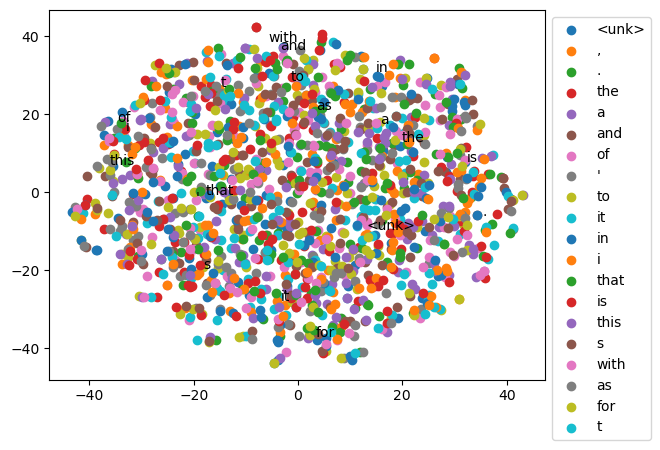

In [179]:
X = model_3.embeddings.weight.cpu().detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

labels = []

for j in range(len(X_2d)):
    if j < 20:
        plt.scatter(X_2d[j, 0], X_2d[j, 1], label=index_to_token[j])
        labels.append(index_to_token[j])
        # Add words as annotations
        plt.annotate(index_to_token[j],
                     (X_2d[j, 0], X_2d[j, 1]),
                      textcoords="offset points",
                     xytext=(0, 10),
                     ha='center')
    else:
        plt.scatter(X_2d[j, 0], X_2d[j, 1])

plt.legend(labels, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

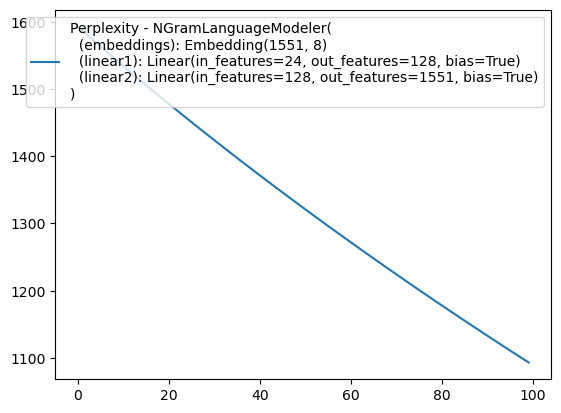

In [181]:
perplexity = np.exp(my_loss)
plt.plot(perplexity,label="Perplexity - {}".format(model_3))
plt.legend()

### Continous Bag of Words Model (CBOW)

In [184]:
CONTEXT_SIZE=5

cobow_data=[]
for token_sent in padded_tokens:
    for i in range(1,len(token_sent)-CONTEXT_SIZE):
        context=(
            [token_sent [i - j - 1] for j in range(CONTEXT_SIZE)]
            + [token_sent [i + j + 1] for j in range(CONTEXT_SIZE)]
        )
        target=token_sent[i]
        cobow_data.append((context,target))

In [187]:
vocab['i']

11

In [196]:
text_pipeline=lambda tokens:[vocab[token] for token in tokens]

In [197]:
def collate_batch(batch):
    target_list, context_list, offsets = [], [], [0]
    for pair in batch:
        target_list.append(vocab[pair[1]])  ## Converting target token to number
        processed_context = torch.tensor(text_pipeline(pair[0]), dtype=torch.int64) ## Converting context tokens to numbers from vocab dixt
        context_list.append(processed_context)
        offsets.append(processed_context.size(0)) ## Appending the size of each context length
    target_list = torch.tensor(target_list, dtype=torch.int64)
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0) ## Lets us know the position from which the next context vector is starting in the concatenated context vector
    context_list = torch.cat(context_list) ## Context tensors are concatenated into one vector side by side
    return target_list.to(device), context_list.to(device), offsets.to(device)

In [198]:
collate_batch(cobow_data[0:5]) ## For example, let cobow_data[0:5] be a batch context,target pairs

(tensor([894,  14,  28,   4, 510]),
 tensor([ 11,   4,  28,  14, 894,  14,  28,   4, 510,  17, 894,  11,   4,  28,
          14,  28,   4, 510,  17,   9,  14, 894,  11,   4,  28,   4, 510,  17,
           9,  13,  28,  14, 894,  11,   4, 510,  17,   9,  13, 495,   4,  28,
          14, 894,  11,  17,   9,  13, 495,  67]),
 tensor([ 0, 10, 20, 30, 40]))

In [201]:
cobow_data[5]

(['3', 'a', 'movie', 'this', 'give', 'it', 'is', 'worse', 'than', 'the'], 'as')

In [200]:
print(text_pipeline(cobow_data[5][0])) ## Picking up the context vector only

[510, 4, 28, 14, 894, 9, 13, 495, 67, 3]


In [202]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [203]:
device

device(type='cpu')

In [207]:
BATCH_SIZE=10

dataloader_cbow=DataLoader(cobow_data,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate_batch)

In [210]:
for idx,samples in enumerate(dataloader_cbow):
    print(idx)
    print(samples)
    
## Check cobow_data to understand that each context vector which are padded have ten tokens only

0
(tensor([894,  14,  28,   4, 510,  17,   9,  13, 495,  67]), tensor([ 11,   4,  28,  14, 894,  14,  28,   4, 510,  17, 894,  11,   4,  28,
         14,  28,   4, 510,  17,   9,  14, 894,  11,   4,  28,   4, 510,  17,
          9,  13,  28,  14, 894,  11,   4, 510,  17,   9,  13, 495,   4,  28,
         14, 894,  11,  17,   9,  13, 495,  67, 510,   4,  28,  14, 894,   9,
         13, 495,  67,   3,  17, 510,   4,  28,  14,  13, 495,  67,   3, 730,
          9,  17, 510,   4,  28, 495,  67,   3, 730,  64,  13,   9,  17, 510,
          4,  67,   3, 730,  64,  12, 495,  13,   9,  17, 510,   3, 730,  64,
         12, 761]), tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]))
1
(tensor([   3,  730,   64,   12,  761,    4, 1229,  286,    2,    9]), tensor([  67,  495,   13,    9,   17,  730,   64,   12,  761,    4,    3,   67,
         495,   13,    9,   64,   12,  761,    4, 1229,  730,    3,   67,  495,
          13,   12,  761,    4, 1229,  286,   64,  730,    3,   67,  495,  761,
        

(tensor([   1,  982,    1,    6,  327, 1164,  450,    1, 1166,  678]), tensor([1073,  471,    6,  242,    3,  982,    1,    6,  327, 1164,    1, 1073,
         471,    6,  242,    1,    6,  327, 1164,  450,  982,    1, 1073,  471,
           6,    6,  327, 1164,  450,    1,    1,  982,    1, 1073,  471,  327,
        1164,  450,    1, 1166,    6,    1,  982,    1, 1073, 1164,  450,    1,
        1166,  678,  327,    6,    1,  982,    1,  450,    1, 1166,  678,   26,
        1164,  327,    6,    1,  982,    1, 1166,  678,   26,   10,  450, 1164,
         327,    6,    1, 1166,  678,   26,   10,  985,    1,  450, 1164,  327,
           6,  678,   26,   10,  985,  264, 1166,    1,  450, 1164,  327,   26,
          10,  985,  264,   25]), tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]))
108
(tensor([  26,   10,  985,  264,   25,    1,  784, 1171,    5,  466]), tensor([ 678, 1166,    1,  450, 1164,   10,  985,  264,   25,    1,   26,  678,
        1166,    1,  450,  985,  264,   25,    1, 

(tensor([818, 191,   2,  11,  85,   7,  19, 139,  42,   9]), tensor([ 397,   44,    1,  450, 1207,  191,    2,   11,   85,    7,  818,  397,
          44,    1,  450,    2,   11,   85,    7,   19,  191,  818,  397,   44,
           1,   11,   85,    7,   19,  139,    2,  191,  818,  397,   44,   85,
           7,   19,  139,   42,   11,    2,  191,  818,  397,    7,   19,  139,
          42,    9,   85,   11,    2,  191,  818,   19,  139,   42,    9,    7,
           7,   85,   11,    2,  191,  139,   42,    9,    7,   15,   19,    7,
          85,   11,    2,   42,    9,    7,   15,  544,  139,   19,    7,   85,
          11,    9,    7,   15,  544,   34,   42,  139,   19,    7,   85,    7,
          15,  544,   34,  102]), tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]))
207
(tensor([  7,  15, 544,  34, 102, 891,   1, 142,   2, 211]), tensor([  9,  42, 139,  19,   7,  15, 544,  34, 102, 891,   7,   9,  42, 139,
         19, 544,  34, 102, 891,   1,  15,   7,   9,  42, 139,  34, 102,

(tensor([   3,  580,    6,    3,  115,    2,  121, 1295,   22, 1024]), tensor([  13,  132,   10, 1341,  178,  580,    6,    3,  115,    2,    3,   13,
         132,   10, 1341,    6,    3,  115,    2,  121,  580,    3,   13,  132,
          10,    3,  115,    2,  121, 1295,    6,  580,    3,   13,  132,  115,
           2,  121, 1295,   22,    3,    6,  580,    3,   13,    2,  121, 1295,
          22, 1024,  115,    3,    6,  580,    3,  121, 1295,   22, 1024,  151,
           2,  115,    3,    6,  580, 1295,   22, 1024,  151,    4,  121,    2,
         115,    3,    6,   22, 1024,  151,    4,  317, 1295,  121,    2,  115,
           3, 1024,  151,    4,  317,    6,   22, 1295,  121,    2,  115,  151,
           4,  317,    6,  670]), tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]))
319
(tensor([151,   4, 317,   6, 670, 404,  68,  16, 240, 230]), tensor([1024,   22, 1295,  121,    2,    4,  317,    6,  670,  404,  151, 1024,
          22, 1295,  121,  317,    6,  670,  404,   68,    4

433
(tensor([1173, 1333,   29,    3,   21, 1450,   50,    1,   46,    9]), tensor([   4,  101,  371,    2,   64, 1333,   29,    3,   21, 1450, 1173,    4,
         101,  371,    2,   29,    3,   21, 1450,   50, 1333, 1173,    4,  101,
         371,    3,   21, 1450,   50,    1,   29, 1333, 1173,    4,  101,   21,
        1450,   50,    1,   46,    3,   29, 1333, 1173,    4, 1450,   50,    1,
          46,    9,   21,    3,   29, 1333, 1173,   50,    1,   46,    9,   36,
        1450,   21,    3,   29, 1333,    1,   46,    9,   36,  241,   50, 1450,
          21,    3,   29,   46,    9,   36,  241,   68,    1,   50, 1450,   21,
           3,    9,   36,  241,   68,   60,   46,    1,   50, 1450,   21,   36,
         241,   68,   60,  236]), tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]))
434
(tensor([  36,  241,   68,   60,  236,    1,   12, 1060,   38,  658]), tensor([   9,   46,    1,   50, 1450,  241,   68,   60,  236,    1,   36,    9,
          46,    1,   50,   68,   60,  236,   

In [212]:
class CBOW(nn.Module):
    # Initialize the CBOW model
    def __init__(self, vocab_size, embed_dim, num_class):
        
        super(CBOW, self).__init__()
        
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False)
        
        self.linear1 = nn.Linear(embed_dim, embed_dim//2)

        self.fc = nn.Linear(embed_dim//2, vocab_size)
        

        self.init_weights()

    def init_weights(self):

        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)

        self.fc.weight.data.uniform_(-initrange, initrange)

        self.fc.bias.data.zero_()
        

    def forward(self, text, offsets):

        out = self.embedding(text, offsets)

        out = torch.relu(self.linear1(out))

        return self.fc(out)

In [213]:
def train_model(model, dataloader, criterion, optimizer, num_epochs=1000):
    """
    Train the model for the specified number of epochs.
    
    Args:
        model: The PyTorch model to be trained.
        dataloader: DataLoader providing data for training.
        criterion: Loss function.
        optimizer: Optimizer for updating model's weights.
        num_epochs: Number of epochs to train the model for.

    Returns:
        model: The trained model.
        epoch_losses: List of average losses for each epoch.
    """
    

    epoch_losses = []

    for epoch in tqdm(range(num_epochs)):

        running_loss = 0.0


        for idx, samples in enumerate(dataloader):

            optimizer.zero_grad()
            
     
            if any(isinstance(module, nn.EmbeddingBag) for _, module in model.named_modules()):
                target, context, offsets = samples
                predicted = model(context, offsets)
            
    
            elif any(isinstance(module, nn.Embedding) for _, module in model.named_modules()):
                target, context = samples
                predicted = model(context)
                
            loss = criterion(predicted, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            running_loss += loss.item()

       
        epoch_losses.append(running_loss / len(dataloader))
    
    return model, epoch_losses

In [214]:
vocab_size = len(vocab)
emsize = 8
model_cbow = CBOW(vocab_size, emsize, vocab_size).to(device)

In [215]:
LR=5

criterion=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model_cbow.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)

In [216]:
model_cbow, epoch_losses=train_model(model_cbow, dataloader_cbow, criterion, optimizer, num_epochs=400)

100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [11:05<00:00,  1.66s/it]


In [218]:
model_cbow.named_modules

<bound method Module.named_modules of CBOW(
  (embedding): EmbeddingBag(1551, 8, mode='mean')
  (linear1): Linear(in_features=8, out_features=4, bias=True)
  (fc): Linear(in_features=4, out_features=1551, bias=True)
)>

In [219]:
epoch_losses

[6.321093042768409,
 6.100623797632509,
 6.05485112062967,
 6.010422426220066,
 5.9684292038819775,
 5.929477246171962,
 5.89626014347925,
 5.86351623110891,
 5.829870553265688,
 5.799039048429154,
 5.771466279168194,
 5.742396143465023,
 5.716640743572892,
 5.691801943677537,
 5.669704344101985,
 5.647469593431779,
 5.625218188509028,
 5.60143111153313,
 5.5790837396736075,
 5.561061948134314,
 5.535701309458661,
 5.506341489647989,
 5.477548824288167,
 5.445801423642806,
 5.414932064207656,
 5.385841424045526,
 5.36016467461503,
 5.33299763751445,
 5.309067797614712,
 5.283043496152188,
 5.260412665815372,
 5.230035153302279,
 5.210591990896996,
 5.181570212661183,
 5.165448607051856,
 5.140099440598626,
 5.115841384090815,
 5.098409158348806,
 5.0737116212309905,
 5.050504499062809,
 5.035944230321298,
 5.012358902040257,
 4.9991400786018,
 4.973937724037834,
 4.963796417302735,
 4.946077619346013,
 4.932458079760495,
 4.919155500382473,
 4.895970452915538,
 4.8834463318727,
 4.8740

Text(0.5, 0, 'epochs')

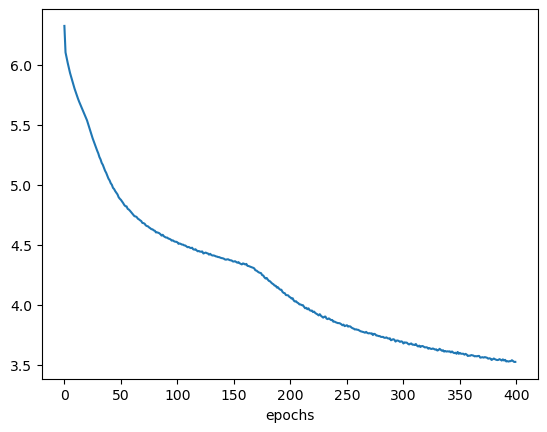

In [221]:
plt.plot(epoch_losses)
plt.xlabel("epochs")

In [222]:
word_embeddings = model_cbow.embedding.weight.detach().cpu().numpy() 

In [223]:
word = 'believable'
word_index = vocab.get_stoi()[word] # getting the index of the word in the vocab
print(word_embeddings[word_index])

[-1.5663861e-01  5.3011643e-04  8.1912500e-01  1.5250289e+00
  5.9898460e-01 -4.7757667e-01  1.5020551e-01  1.1104429e+00]


In [224]:
def plot_embeddings(word_embeddings,vocab=vocab):

    tsne = TSNE(n_components=2, random_state=0)
    word_embeddings_2d = tsne.fit_transform(word_embeddings)

    # Plotting the results with labels from vocab
    plt.figure(figsize=(15, 15))
    for i, word in enumerate(vocab.get_itos()):  # assuming vocab.itos gives the list of words in your vocab
        plt.scatter(word_embeddings_2d[i, 0], word_embeddings_2d[i, 1])  ## gives the x and y value
        plt.annotate(word, (word_embeddings_2d[i, 0], word_embeddings_2d[i, 1]))

    plt.xlabel("t-SNE component 1")
    plt.ylabel("t-SNE component 2")
    plt.title("Word Embeddings visualized with t-SNE")
    plt.show()

IndexError: index 500 is out of bounds for axis 0 with size 500

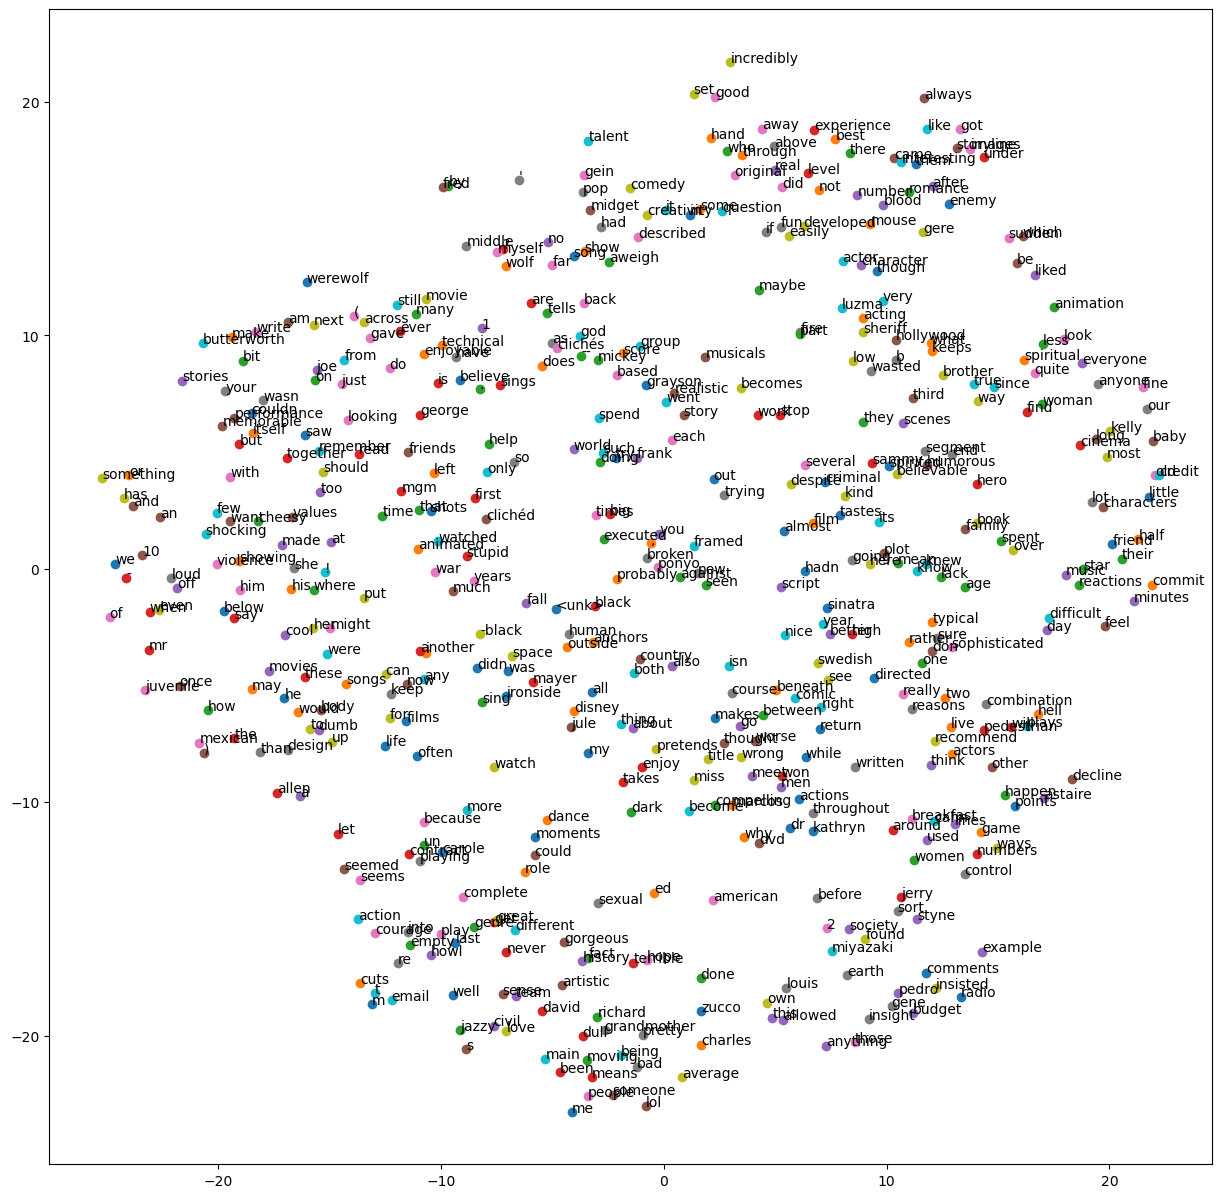

In [228]:
plot_embeddings(word_embeddings[0:500],vocab)

In [230]:
# This function returns the most similar words to a target word by calculating word vectors' cosine distance
def find_similar_words(word, word_embeddings, top_k=5):
    if word not in word_embeddings:
        print("Word not found in embeddings.")
        return []

    
    target_embedding = word_embeddings[word]


    similarities = {}
    for w, embedding in word_embeddings.items():
        if w != word:
            similarity = torch.dot(target_embedding, embedding) / (
                torch.norm(target_embedding) * torch.norm(embedding)
            )
            similarities[w] = similarity.item()

    sorted_similarities = sorted(similarities.items(), key=lambda x: x[1], reverse=True)

    most_similar_words = [w for w, _ in sorted_similarities[:top_k]]
    return most_similar_words

In [231]:
embedding_dict_Glove6B = {}
for word in vocab.get_itos():
    
    embedding_vector = model_cbow.embedding.weight[vocab.get_stoi()[word]]
    if embedding_vector is not None:
        
        embedding_dict_Glove6B[word] = embedding_vector

In [233]:
target_word = "believable"
top_k=4
similar_words = find_similar_words(target_word, embedding_dict_Glove6B, top_k)

# Print the similar words
print("{} most similar words to {}:".format(top_k,target_word) ,similar_words)

4 most similar words to believable: ['yes', 'end', 'hyde', 'washed']


In [234]:

CONTEXT_SIZE = 2

skip_data = []


for token_sent in padded_tokens:
    
    for i in range(CONTEXT_SIZE, len(token_sent) - CONTEXT_SIZE):

        context = (
            [token_sent[i - j - 1] for j in range(CONTEXT_SIZE)]  
            + [token_sent[i + j + 1] for j in range(CONTEXT_SIZE)]  
        )

 
        target = token_sent[i]

        skip_data.append((target, context))


In [236]:
skip_data[0:5]

[('this', ['give', 'i', 'movie', 'a']),
 ('movie', ['this', 'give', 'a', '3']),
 ('a', ['movie', 'this', '3', 'as']),
 ('3', ['a', 'movie', 'as', 'it']),
 ('as', ['3', 'a', 'it', 'is'])]

In [237]:
skip_data_=[[(sample[0],word) for word in  sample[1]] for sample in skip_data]
skip_data_[0:5]

[[('this', 'give'), ('this', 'i'), ('this', 'movie'), ('this', 'a')],
 [('movie', 'this'), ('movie', 'give'), ('movie', 'a'), ('movie', '3')],
 [('a', 'movie'), ('a', 'this'), ('a', '3'), ('a', 'as')],
 [('3', 'a'), ('3', 'movie'), ('3', 'as'), ('3', 'it')],
 [('as', '3'), ('as', 'a'), ('as', 'it'), ('as', 'is')]]

In [238]:
skip_data_flat=[item for items in skip_data_ for item in items]
skip_data_flat[0:10]

[('this', 'give'),
 ('this', 'i'),
 ('this', 'movie'),
 ('this', 'a'),
 ('movie', 'this'),
 ('movie', 'give'),
 ('movie', 'a'),
 ('movie', '3'),
 ('a', 'movie'),
 ('a', 'this')]

In [239]:
def collate_batch(batch):
    target_list, context_list = [], []
    for pair in batch:
        
        target_list.append(vocab[pair[0]])  
        context_list.append(vocab[pair[1]])
    
    target_list = torch.tensor(target_list, dtype=torch.int64)
    context_list = torch.tensor(context_list) 
    return target_list.to(device), context_list.to(device)

In [240]:
collate_batch(skip_data_flat[0:5])

(tensor([14, 14, 14, 14, 28]), tensor([894,  11,  28,   4,  14]))

In [241]:
BATCH_SIZE=5
dataloader=DataLoader(skip_data_flat,batch_size=BATCH_SIZE,collate_fn=collate_batch)

In [242]:
for items in dataloader:
    print("Target", items[0])
    print("Context",items[1])
    print("\n")

Target tensor([14, 14, 14, 14, 28])
Context tensor([894,  11,  28,   4,  14])


Target tensor([28, 28, 28,  4,  4])
Context tensor([894,   4, 510,  28,  14])


Target tensor([  4,   4, 510, 510, 510])
Context tensor([510,  17,   4,  28,  17])


Target tensor([510,  17,  17,  17,  17])
Context tensor([  9, 510,   4,   9,  13])


Target tensor([ 9,  9,  9,  9, 13])
Context tensor([ 17, 510,  13, 495,   9])


Target tensor([ 13,  13,  13, 495, 495])
Context tensor([ 17, 495,  67,  13,   9])


Target tensor([495, 495,  67,  67,  67])
Context tensor([ 67,   3, 495,  13,   3])


Target tensor([67,  3,  3,  3,  3])
Context tensor([730,  67, 495, 730,  64])


Target tensor([730, 730, 730, 730,  64])
Context tensor([  3,  67,  64,  12, 730])


Target tensor([64, 64, 64, 12, 12])
Context tensor([  3,  12, 761,  64, 730])


Target tensor([ 12,  12, 761, 761, 761])
Context tensor([761,   4,  12,  64,   4])


Target tensor([761,   4,   4,   4,   4])
Context tensor([1229,  761,   12, 1229,  286])




Context tensor([ 10,   3, 447,   4,   3])


Target tensor([10,  3,  3,  3,  3])
Context tensor([ 81,  10, 447,  81,  26])


Target tensor([81, 81, 81, 81, 26])
Context tensor([ 3, 10, 26, 17, 81])


Target tensor([26, 26, 26, 17, 17])
Context tensor([ 3, 17, 40, 26, 81])


Target tensor([17, 17, 40, 40, 40])
Context tensor([40, 54, 17, 26, 54])


Target tensor([40, 54, 54, 54, 54])
Context tensor([800,  40,  17, 800,  12])


Target tensor([800, 800, 800, 800,  12])
Context tensor([ 54,  40,  12, 447, 800])


Target tensor([ 12,  12,  12, 447, 447])
Context tensor([ 54, 447,  10,  12, 800])


Target tensor([447, 447,  10,  10,  10])
Context tensor([ 10,   3, 447,  12,   3])


Target tensor([10,  3,  3,  3,  3])
Context tensor([319,  10, 447, 319,  25])


Target tensor([319, 319, 319, 319,  25])
Context tensor([  3,  10,  25,   2, 319])


Target tensor([25, 25, 25,  2,  2])
Context tensor([  3,   2,  57,  25, 319])


Target tensor([ 2,  2, 57, 57, 57])
Context tensor([57, 24,  2, 25, 24]

Target tensor([85,  7,  7,  7,  7])
Context tensor([ 19,  85,  23,  19, 566])


Target tensor([ 19,  19,  19,  19, 566])
Context tensor([  7,  85, 566,  50,  19])


Target tensor([566, 566, 566,  50,  50])
Context tensor([  7,  50,   8, 566,  19])


Target tensor([50, 50,  8,  8,  8])
Context tensor([  8, 210,  50, 566, 210])


Target tensor([  8, 210, 210, 210, 210])
Context tensor([297,   8,  50, 297,  10])


Target tensor([297, 297, 297, 297,  10])
Context tensor([210,   8,  10,  14, 297])


Target tensor([10, 10, 10, 14, 14])
Context tensor([210,  14, 162,  10, 297])


Target tensor([ 14,  14, 162, 162, 162])
Context tensor([162,   6,  14,  10,   6])


Target tensor([162,   6,   6,   6,   6])
Context tensor([977, 162,  14, 977, 690])


Target tensor([977, 977, 977, 977, 690])
Context tensor([  6, 162, 690,  12, 977])


Target tensor([690, 690, 690,  12,  12])
Context tensor([  6,  12, 455, 690, 977])


Target tensor([ 12,  12, 455, 455, 455])
Context tensor([455,  36,  12, 690,  36

Target tensor([  2,   2, 286, 286, 286])
Context tensor([286,  25,   2, 153,  25])


Target tensor([286,  25,  25,  25,  25])
Context tensor([ 31, 286,   2,  31,   8])


Target tensor([31, 31, 31, 31,  8])
Context tensor([ 25, 286,   8,  35,  31])


Target tensor([ 8,  8,  8, 35, 35])
Context tensor([25, 35, 37,  8, 31])


Target tensor([35, 35, 37, 37, 37])
Context tensor([ 37, 540,  35,   8, 540])


Target tensor([ 37, 540, 540, 540, 540])
Context tensor([  2,  37,  35,   2, 146])


Target tensor([  2,   2,   2,   2, 146])
Context tensor([540,  37, 146,  14,   2])


Target tensor([146, 146, 146,  14,  14])
Context tensor([540,  14, 361, 146,   2])


Target tensor([ 14,  14, 361, 361, 361])
Context tensor([361,   5,  14, 146,   5])


Target tensor([361,   5,   5,   5,   5])
Context tensor([ 24, 361,  14,  24, 283])


Target tensor([ 24,  24,  24,  24, 283])
Context tensor([  5, 361, 283,   7,  24])


Target tensor([283, 283, 283,   7,   7])
Context tensor([  5,   7,  19, 283,  24])




Context tensor([  39,    4, 1401,  195,    4])


Target tensor([39,  4,  4,  4,  4])
Context tensor([ 398,   39, 1401,  398,  214])


Target tensor([398, 398, 398, 398, 214])
Context tensor([  4,  39, 214,   5, 398])


Target tensor([214, 214, 214,   5,   5])
Context tensor([   4,    5, 1361,  214,  398])


Target tensor([   5,    5, 1361, 1361, 1361])
Context tensor([1361,  312,    5,  214,  312])


Target tensor([1361,  312,  312,  312,  312])
Context tensor([1502, 1361,    5, 1502,    2])


Target tensor([1502, 1502, 1502, 1502,    2])
Context tensor([ 312, 1361,    2,   85, 1502])


Target tensor([ 2,  2,  2, 85, 85])
Context tensor([ 312,   85,    7,    2, 1502])


Target tensor([85, 85,  7,  7,  7])
Context tensor([ 7, 19, 85,  2, 19])


Target tensor([ 7, 19, 19, 19, 19])
Context tensor([1093,    7,   85, 1093,   12])


Target tensor([1093, 1093, 1093, 1093,   12])
Context tensor([  19,    7,   12,    8, 1093])


Target tensor([12, 12, 12,  8,  8])
Context tensor([  19,    8,  4

...

Target tensor([ 22,  22,  22,  22, 618])
Context tensor([614,  10, 618,   5,  22])


Target tensor([618, 618, 618,   5,   5])
Context tensor([614,   5,  12, 618,  22])


Target tensor([ 5,  5, 12, 12, 12])
Context tensor([ 12,   7,   5, 618,   7])


Target tensor([12,  7,  7,  7,  7])
Context tensor([ 15,  12,   5,  15, 101])


Target tensor([ 15,  15,  15,  15, 101])
Context tensor([  7,  12, 101, 622,  15])


Target tensor([101, 101, 101, 622, 622])
Context tensor([  7, 622,  48, 101,  15])


Target tensor([622, 622,  48,  48,  48])
Context tensor([ 48,   8, 622, 101,   8])


Target tensor([48,  8,  8,  8,  8])
Context tensor([235,  48, 622, 235,   2])


Target tensor([235, 235, 235, 235,   2])
Context tensor([  8,  48,   2,  11, 235])


Target tensor([ 2,  2,  2, 11, 11])
Context tensor([  8,  11,  27,   2, 235])


Target tensor([11, 11, 27, 27, 27])
Context tensor([27,  4, 11,  2,  4])


Target tensor([27,  4,  4,  4,  4])
Context tensor([1413,   27,   11, 1413,   97])


Target ten

Target tensor([ 267,  267, 1356, 1356, 1356])
Context tensor([1356,   21,  267,  770,   21])


Target tensor([1356,   21,   21,   21,   21])
Context tensor([  16, 1356,  267,   16,   66])


Target tensor([16, 16, 16, 16, 66])
Context tensor([  21, 1356,   66,   42,   16])


Target tensor([66, 66, 66, 42, 42])
Context tensor([21, 42, 33, 66, 16])


Target tensor([42, 42, 33, 33, 33])
Context tensor([ 33, 844,  42,  66, 844])


Target tensor([ 33, 844, 844, 844, 844])
Context tensor([226,  33,  42, 226,  39])


Target tensor([226, 226, 226, 226,  39])
Context tensor([ 844,   33,   39, 1097,  226])


Target tensor([  39,   39,   39, 1097, 1097])
Context tensor([ 844, 1097,    2,   39,  226])


Target tensor([1097, 1097,    2,    2,    2])
Context tensor([   2,   12, 1097,   39,   12])


Target tensor([ 2, 12, 12, 12, 12])
Context tensor([ 565,    2, 1097,  565,    1])


Target tensor([565, 565, 565, 565,   1])
Context tensor([ 12,   2,   1,   9, 565])


Target tensor([1, 1, 1, 9, 9])
Cont

Target tensor([902, 902, 902,   9,   9])
Context tensor([1529,    9,    1,  902,    5])


Target tensor([9, 9, 1, 1, 1])
Context tensor([  1,  23,   9, 902,  23])


Target tensor([ 1, 23, 23, 23, 23])
Context tensor([18,  1,  9, 18,  3])


Target tensor([18, 18, 18, 18,  3])
Context tensor([23,  1,  3, 78, 18])


Target tensor([ 3,  3,  3, 78, 78])
Context tensor([ 23,  78, 422,   3,  18])


Target tensor([ 78,  78, 422, 422, 422])
Context tensor([422,  14,  78,   3,  14])


Target tensor([422,  14,  14,  14,  14])
Context tensor([ 13, 422,  78,  13,   4])


Target tensor([13, 13, 13, 13,  4])
Context tensor([  14,  422,    4, 1289,   13])


Target tensor([   4,    4,    4, 1289, 1289])
Context tensor([  14, 1289,    5,    4,   13])


Target tensor([1289, 1289,    5,    5,    5])
Context tensor([   5,  423, 1289,    4,  423])


Target tensor([  5, 423, 423, 423, 423])
Context tensor([  53,    5, 1289,   53,   99])


Target tensor([53, 53, 53, 53, 99])
Context tensor([423,   5,  99, 423

Context tensor([1547,  918,   50, 1547,   11])


Target tensor([1547, 1547, 1547, 1547,   11])
Context tensor([  29,  918,   11,  279, 1547])


Target tensor([ 11,  11,  11, 190, 190])
Context tensor([ 29, 279,  14,  93,  11])


Target tensor([190, 190,  14,  14,  14])
Context tensor([ 14,  21, 190,  93,  21])


Target tensor([14, 21, 21, 21, 21])
Context tensor([ 10,  14, 190,  10, 508])


Target tensor([ 10,  10,  10,  10, 508])
Context tensor([ 21,  14, 508,  10,  10])


Target tensor([508, 508, 508,  10,  10])
Context tensor([ 21,  10,   3, 508,  10])


Target tensor([10, 10,  3,  3,  3])
Context tensor([   3, 1078,   10,  508, 1078])


Target tensor([   3, 1078, 1078, 1078, 1078])
Context tensor([  28,    3,   10,   28, 1381])


Target tensor([  28,   28,   28,   28, 1381])
Context tensor([1078,    3, 1381,    2,   28])


Target tensor([1381, 1381, 1381,    2,    2])
Context tensor([1078,    2,  124, 1381,   28])


Target tensor([  2,   2, 124, 124, 124])
Context tensor([ 124,  18

Target tensor([21,  2,  2,  2,  2])
Context tensor([ 9, 21,  3,  9, 20])


Target tensor([ 9,  9,  9,  9, 20])
Context tensor([  2,  21,  20, 147,   9])


Target tensor([ 20,  20,  20, 147, 147])
Context tensor([  2, 147, 324,  20,   9])


Target tensor([147, 147, 324, 324, 324])
Context tensor([ 324, 1319,  147,   20, 1319])


Target tensor([ 324, 1319, 1319, 1319, 1319])
Context tensor([135, 324, 147, 135, 246])


Target tensor([135, 135, 135, 135, 246])
Context tensor([1319,  324,  246,   49,  135])


Target tensor([246, 246, 246,  49,  49])
Context tensor([1319,   49,    4,  246,  135])


Target tensor([49, 49,  4,  4,  4])
Context tensor([  4, 307,  49, 246, 307])


Target tensor([  4, 307, 307, 307, 307])
Context tensor([1050,    4,   49, 1050,   34])


Target tensor([1050, 1050, 1050, 1050,   34])
Context tensor([ 307,    4,   34,    3, 1050])


Target tensor([34, 34, 34,  3,  3])
Context tensor([ 307,    3,  107,   34, 1050])


Target tensor([  3,   3, 107, 107, 107])
Context t

In [243]:
class SkipGram_Model(nn.Module):
    def __init__(self,vocab_size,embed_dim):
        super(SkipGram_Model,self).__init__()
        self.embeddings=nn.Embedding(num_embeddings=vocab_size,embedding_dim=embed_dim)
        self.fc=nn.Linear(in_features=embed_dim,out_features=vocab_size)
        
    def forward(self,text):
        out=self.embeddings(text)
        out=torch.relu(out)
        out=self.fc(out)
        
        return out

In [244]:
emsize = 8
model_sg = SkipGram_Model(vocab_size, emsize).to("cpu")

In [245]:
model_sg.parameters()

<generator object Module.parameters at 0x00000246C417E0B0>

In [246]:
LR = 5  
BATCH_SIZE = 5  

criterion = torch.nn.CrossEntropyLoss() 
optimizer = torch.optim.SGD(model_sg.parameters(), lr=LR)   
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)

In [247]:
model_sg, epoch_losses=train_model(model_sg, dataloader, criterion, optimizer, num_epochs=200)

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [43:32<00:00, 13.06s/it]


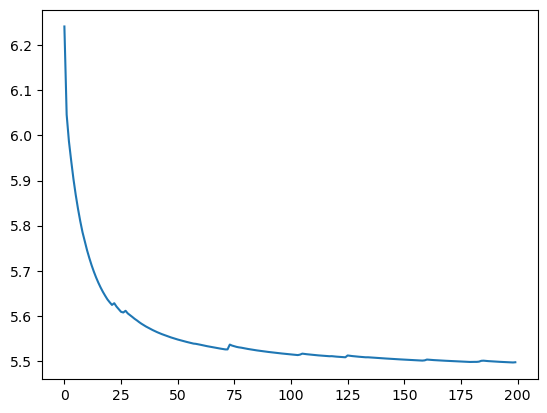

In [248]:
plt.plot(epoch_losses)

C:\Users\Amrita\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


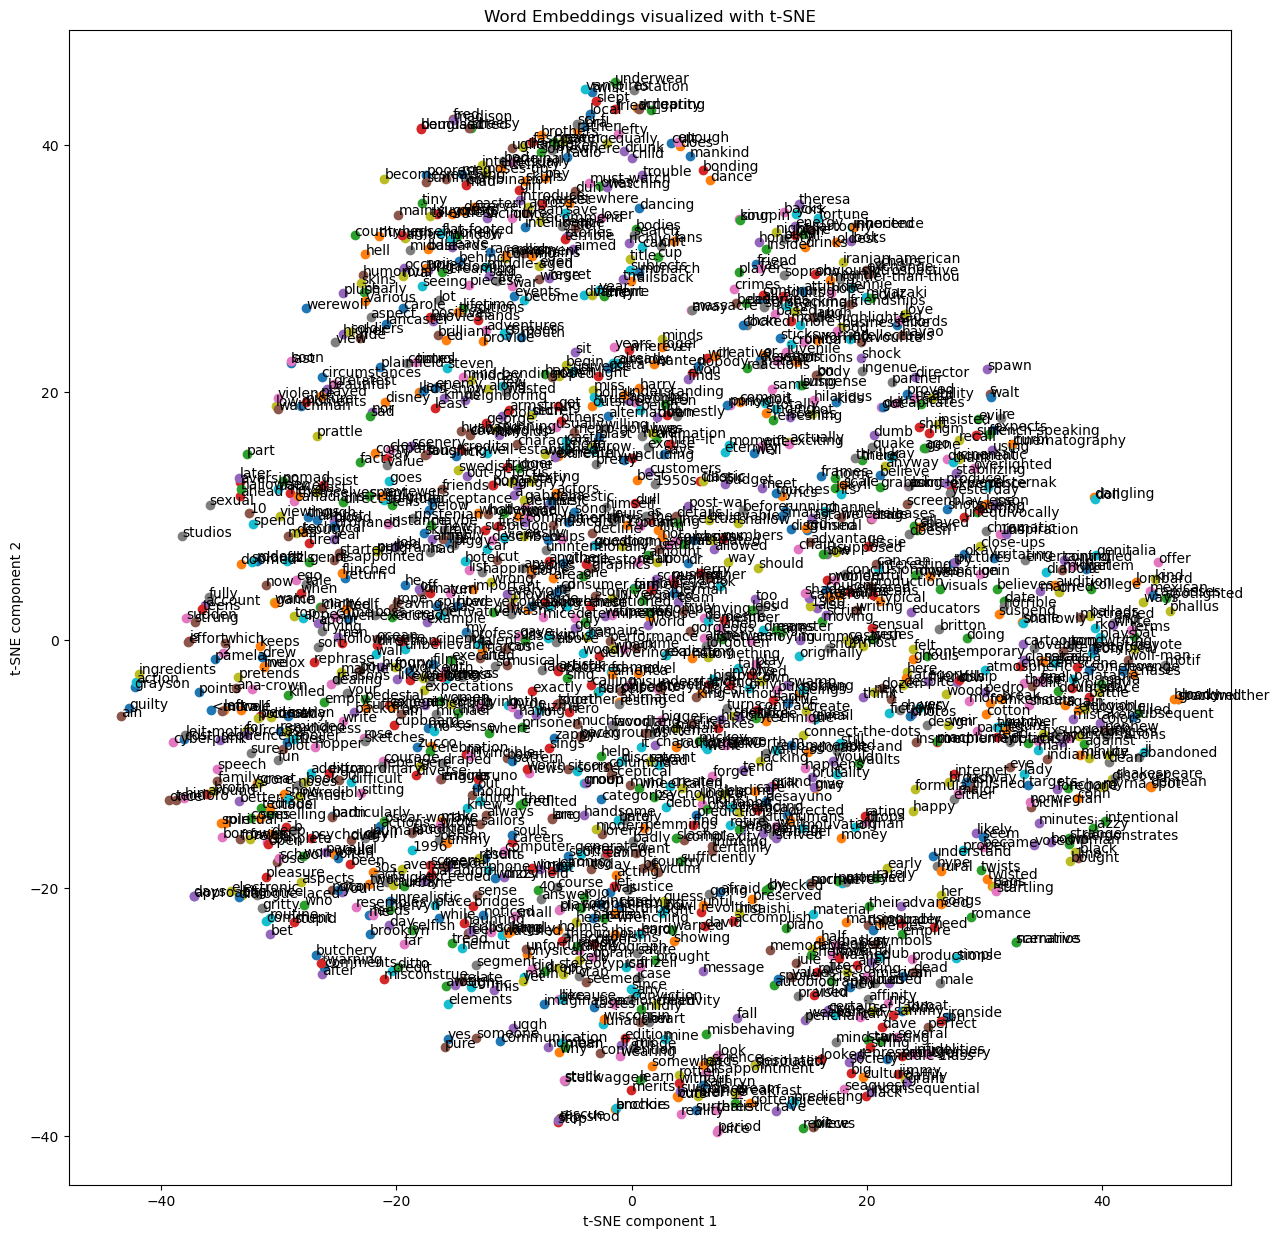

In [249]:
word_embeddings = model_sg.embeddings.weight.detach().cpu().numpy() 
plot_embeddings(word_embeddings,vocab=vocab)

In [250]:
from gensim.models import Word2Vec

In [261]:
sentences = [["I", "like", "to", "eat", "pizza"],
             ["Pizza", "is", "my", "favorite", "food"],
             ["I", "enjoy", "eating", "pasta"]]
sentences = [[word.lower() for word in sentence] for sentence in sentences]


In [262]:
w2v=Word2Vec(sentences, vector_size=5, min_count=1)

In [264]:
w2v.build_vocab(sentences, progress_per=10000)

In [267]:
# Finding similar words
similar_words = w2v.wv.most_similar("pizza")
print("Similar words to 'pizza':", similar_words)

# Calculating word similarity
similarity = w2v.wv.similarity("pizza", "pasta")
print("Similarity between 'pizza' and 'pasta':", similarity)

Similar words to 'pizza': [('enjoy', 0.41506773233413696), ('like', 0.07262038439512253), ('pasta', 0.008028656244277954), ('eating', -0.05969700589776039), ('to', -0.06712116301059723), ('my', -0.08403753489255905), ('i', -0.11381612718105316), ('is', -0.15355797111988068), ('favorite', -0.29979774355888367), ('eat', -0.3469080626964569)]
Similarity between 'pizza' and 'pasta': 0.008028658


In [265]:
w2v.train(sentences, total_examples=w2v.corpus_count, epochs=30, report_delay=1)

(53, 420)

In [269]:
w2v.wv.index_to_key
w2v.wv.key_to_index

{'pizza': 0,
 'i': 1,
 'pasta': 2,
 'eating': 3,
 'enjoy': 4,
 'food': 5,
 'favorite': 6,
 'my': 7,
 'is': 8,
 'eat': 9,
 'to': 10,
 'like': 11}

In [271]:
word_vectors = w2v.wv
word_vectors[8]

array([-0.06829835, -0.01892648,  0.11550561, -0.15056115, -0.07872937],
      dtype=float32)

In [272]:
word_to_index = {word: index for index, word in enumerate(word_vectors.index_to_key)}
word_to_index

{'pizza': 0,
 'i': 1,
 'pasta': 2,
 'eating': 3,
 'enjoy': 4,
 'food': 5,
 'favorite': 6,
 'my': 7,
 'is': 8,
 'eat': 9,
 'to': 10,
 'like': 11}

In [273]:
w2v.vector_size

5

In [274]:
embedding_dim = w2v.vector_size
embedding = torch.nn.Embedding(len(word_vectors.index_to_key), embedding_dim)
embedding.weight.data.copy_(torch.from_numpy(word_vectors.vectors))

tensor([[ 0.1462,  0.1014,  0.1352,  0.0153,  0.1270],
        [-0.0108,  0.0046,  0.1023,  0.1801, -0.1860],
        [-0.0893,  0.0903, -0.1357, -0.0709,  0.1880],
        [-0.1633,  0.0900, -0.0827,  0.0164,  0.1700],
        [-0.0060, -0.1532,  0.1924,  0.0995,  0.1846],
        [-0.1922,  0.1001, -0.1750, -0.0879, -0.0007],
        [-0.0388,  0.1615, -0.1185,  0.0009, -0.0951],
        [-0.1503, -0.0186,  0.1908, -0.1464, -0.0466],
        [-0.0683, -0.0189,  0.1155, -0.1506, -0.0787],
        [-0.0364,  0.0575,  0.0199, -0.1658, -0.1890],
        [ 0.1474, -0.0307, -0.0905,  0.1310, -0.0972],
        [-0.1423,  0.1292,  0.1795, -0.1003, -0.0753]])

## Text Classification using pretrained word embeddings

In [278]:
glove_vectors_6B = GloVe(name ='6B') 
embeddings_Glove6B = torch.nn.Embedding.from_pretrained(glove_vectors_6B.vectors,freeze=True)
word_to_index = glove_vectors_6B.stoi  # Vocabulary index mapping

100%|███████████████████████████████████████████████████████████████████████▉| 400000/400001 [02:20<00:00, 2852.29it/s]


In [340]:
vocab = vocab(glove_vectors_6B.stoi, 0,specials=('<unk>', '<pad>'))
vocab.set_default_index(vocab["<unk>"])

In [341]:
tokenizer = get_tokenizer("basic_english")

In [286]:
# Split the dataset into training and testing iterators.
from torchtext.datasets import AG_NEWS
train_iter, test_iter = AG_NEWS()


train_dataset = to_map_style_dataset(train_iter)

test_dataset = to_map_style_dataset(test_iter)

num_train = int(len(train_dataset) * 0.85)


from torch.utils.data.dataset import random_split
split_train_, split_valid_ = random_split(train_dataset, [num_train, len(train_dataset) - num_train])

In [ ]:
## Dataset shape (label,text)

In [321]:
print(split_train_[47718])
# split_train_.indices

(1, 'U.S. Official: No Prospect of Bargain on Iran Nukes (Reuters) Reuters - The United States sees no reason to\\offer Iran incentives to ensure its nuclear program remains\\peaceful, a U.S. government official said on Tuesday.')


In [315]:
# define class labels
ag_news_label = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tec"}
'''ag_news_label[y]'''
num_class = len(set([label for (label, text) in train_iter ]))

In [330]:
def text_pipeline(x):
    x=x.lower()# you need this as your vocab is in lower case
    return vocab(tokenizer(x))

def label_pipeline(x):
    return int(x) - 1

def collate_batch(batch):
    label_list, text_list, offsets = [], [], [0]
    for _label, _text in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
        offsets.append(processed_text.size(0))

    label_list = torch.tensor(label_list, dtype=torch.int64)
    offsets = torch.tensor(offsets).cumsum(dim=0)
    text_list = torch.cat(text_list)
    return label_list.to(device), text_list.to(device), offsets.to(device)


In [342]:
BATCH_SIZE = 64

train_dataloader = DataLoader(
    split_train_, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
valid_dataloader = DataLoader(
    split_valid_, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)

In [348]:
class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_class):
        super(TextClassificationModel, self).__init__()
        self.embedding = torch.nn.Embedding.from_pretrained(glove_vectors_6B.vectors,freeze=True)
        self.fc = nn.Linear(embed_dim, num_class)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, text,offsets):
        embedded = self.embedding(text)
        # you get the average of word embeddings in the text
        means = []
        for i in range(1,len(offsets)):
            text_tmp = embedded[offsets[i-1]:offsets[i]]
            means.append(text_tmp.mean(0))

        return self.fc(torch.stack(means))

In [349]:
def evaluate(dataloader):
    model.eval()
    total_acc, total_count= 0, 0

    with torch.no_grad():
        for idx, (label, text, offsets) in enumerate(dataloader):
            predicted_label = model(text,offsets)

            total_acc += (predicted_label.argmax(1) == label).sum().item()
            total_count += label.size(0)
    return total_acc / total_count

In [350]:
# Define hyperparameters
vocab_size=len(vocab)
embedding_dim = 300
# Initialize the model
model = TextClassificationModel(vocab_size, embedding_dim, num_class).to(device)

In [351]:
evaluate(test_dataloader)

0.24289473684210527

In [352]:
def train_TextClassification(model,dataloader,criterion,optimizer,epochs=10):
    
    cum_loss_list=[]
    acc_epoch=[]
    acc_old=0

    for epoch in tqdm(range(1, EPOCHS + 1)):
        model.train()
        cum_loss=0
        for idx, (label, text, offsets) in enumerate(train_dataloader):
            means = []
            optimizer.zero_grad()
            

            predicted_label = model(text, offsets)
            
            loss = criterion(predicted_label, label)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            cum_loss+=loss.item()

        cum_loss_list.append(cum_loss/len(train_dataloader))
        accu_val = evaluate(valid_dataloader)
        acc_epoch.append(accu_val)

        if accu_val > acc_old:
            acc_old= accu_val
            torch.save(model.state_dict(), 'my_model.pth')
            
    return model,cum_loss_list,acc_epoch


In [353]:
# Define hyperparameters
LR=0.1
EPOCHS = 10


criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)

model,cum_loss_list,acc_epoch  = train_TextClassification(model,train_dataloader,criterion,optimizer,EPOCHS)

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [07:45<00:00, 46.58s/it]


In [354]:
import matplotlib.pyplot as plt
def plot(COST,ACC):
    fig, ax1 = plt.subplots()
    color = 'tab:red'
    ax1.plot(COST, color=color)
    ax1.set_xlabel('epoch', color=color)
    ax1.set_ylabel('total loss', color=color)
    ax1.tick_params(axis='y', color=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('accuracy', color=color)  # you already handled the x-label with ax1
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis='y', color=color)
    fig.tight_layout()  # otherwise the right y-label is slightly clipped

    plt.show()

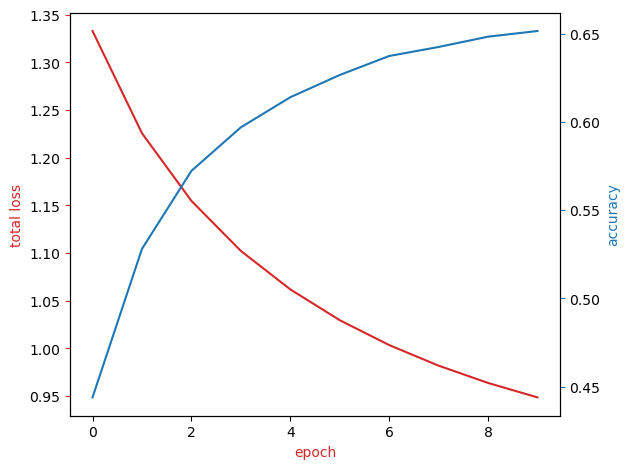

In [355]:
plot(cum_loss_list,acc_epoch)

In [356]:
evaluate(test_dataloader)

0.6506578947368421